http://localhost:8888/notebooks/FaSt-SWOT/Drifters/SOCIB_drifters_thredds_ALL_Chl_230508_allDrifters.ipynb

In [1]:
#venv py3_parcels_DIAG
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
import xarray as xr
import cmocean
import datetime
import json
import matplotlib.colors as colors


# 1. Loading the data:

## Drifters

https://www.socib.es/?seccion=observingFacilities&facility=lagrangianPlatforms

In [2]:
url_root = "http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/"

### CARTHE

In [3]:
url_vars_car = "trajectory,time[0:1:-1],LAT[0:1:-1],QC_LAT[0:1:-1],LON[0:1:-1],QC_LON[0:1:-1],DEPTH,PLAT_SPEED_GR[0:1:-1],QC_PLAT_SPEED_GR[0:1:-1],BAT_STATUS[0:1:-1]"
# CARTHE no course, but HEREON yes dunno why

In [4]:
url_01 = url_root + "drifter_carthe015-ime_carthe010/L1/2023/dep0001_drifter-carthe015_ime-carthe010_L1_2023-04-28.nc?" + url_vars_car
ds_car010 = xr.open_dataset(url_01)

In [5]:
mm = '4'.zfill(2)

#8: 27/04
drifter_num = '8'.zfill(3)
# for some reason to id numbers..
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '27'.zfill(2)
url_01 = url_root + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L1/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L1_2023-" + mm + "-" + dd + ".nc?" + url_vars_car
ds_car008 = xr.open_dataset(url_01)

#07: 27/04
drifter_num = '7'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '27'.zfill(2)
url_01 = url_root + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L1/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L1_2023-" + mm + "-" + dd + ".nc?" + url_vars_car
ds_car007 = xr.open_dataset(url_01)

#06: 27/04
drifter_num = '6'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '27'.zfill(2)
url_01 = url_root + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L1/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L1_2023-" + mm + "-" + dd + ".nc?" + url_vars_car
ds_car006 = xr.open_dataset(url_01)

#05: 27/04
drifter_num = '5'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '27'.zfill(2)
url_01 = url_root + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L1/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L1_2023-" + mm + "-" + dd + ".nc?" + url_vars_car
ds_car005 = xr.open_dataset(url_01)

#04: 27/04
drifter_num = '4'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '27'.zfill(2)
url_01 = url_root + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L1/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L1_2023-" + mm + "-" + dd + ".nc?" + url_vars_car
ds_car004 = xr.open_dataset(url_01)

#03: 26/04
drifter_num = '3'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '26'.zfill(2)
url_01 = url_root + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L1/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L1_2023-" + mm + "-" + dd + ".nc?" + url_vars_car
ds_car003 = xr.open_dataset(url_01)

#02: 26/04
drifter_num = '2'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '26'.zfill(2)
url_01 = url_root + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L1/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L1_2023-" + mm + "-" + dd + ".nc?" + url_vars_car
ds_car002 = xr.open_dataset(url_01)

#01: 26/04
drifter_num = '1'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '26'.zfill(2)
# attention! prev trial done, so here dep0001_ is dep0002_
url_01 = url_root + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L1/2023/dep0002_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L1_2023-" + mm + "-" + dd + ".nc?" + url_vars_car
print(url_01)
ds_car001 = xr.open_dataset(url_01)

#09: 24/04
drifter_num = '9'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '28'.zfill(2)
url_01 = url_root + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L1/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L1_2023-" + mm + "-" + dd + ".nc?" + url_vars_car
ds_car009 = xr.open_dataset(url_01)


http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe006-ime_carthe001/L1/2023/dep0002_drifter-carthe006_ime-carthe001_L1_2023-04-26.nc?trajectory,time[0:1:-1],LAT[0:1:-1],QC_LAT[0:1:-1],LON[0:1:-1],QC_LON[0:1:-1],DEPTH,PLAT_SPEED_GR[0:1:-1],QC_PLAT_SPEED_GR[0:1:-1],BAT_STATUS[0:1:-1]


In [6]:
ds_car_leg1 = [ds_car001, ds_car002, ds_car003
                        ,ds_car004, ds_car005, ds_car006, ds_car007 ,ds_car008
                        ,ds_car009, ds_car010]

In [7]:
mm = '5'.zfill(2)

#11: 08/05
drifter_num = '11'.zfill(3)
# for some reason to id numbers..
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '8'.zfill(2)
url_01 = url_root + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L1/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L1_2023-" + mm + "-" + dd + ".nc?" + url_vars_car
ds_car011 = xr.open_dataset(url_01)
# https://thredds.socib.es/thredds/catalog/drifter/surface_drifter/drifter_carthe016-ime_carthe011/L1/2023/catalog.html

#12: 08/05
drifter_num = '12'.zfill(3)
# for some reason to id numbers..
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '8'.zfill(2)
url_01 = url_root + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L1/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L1_2023-" + mm + "-" + dd + ".nc?" + url_vars_car
ds_car012 = xr.open_dataset(url_01)

#13: 08/05
drifter_num = '13'.zfill(3)
# for some reason to id numbers..
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '8'.zfill(2)
url_01 = url_root + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L1/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L1_2023-" + mm + "-" + dd + ".nc?" + url_vars_car
ds_car013 = xr.open_dataset(url_01)

#14: 09/05
drifter_num = '14'.zfill(3)
# for some reason to id numbers..
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '9'.zfill(2)
url_01 = url_root + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L1/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L1_2023-" + mm + "-" + dd + ".nc?" + url_vars_car
ds_car014 = xr.open_dataset(url_01)

#15: 10/05
drifter_num = '15'.zfill(3)
# for some reason to id numbers..
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '10'.zfill(2)
url_01 = url_root + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L1/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L1_2023-" + mm + "-" + dd + ".nc?" + url_vars_car
ds_car015 = xr.open_dataset(url_01)

#16: 10/05
drifter_num = '16'.zfill(3)
# for some reason to id numbers..
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '10'.zfill(2)
url_01 = url_root + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L1/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L1_2023-" + mm + "-" + dd + ".nc?" + url_vars_car
ds_car016 = xr.open_dataset(url_01)

#17: 10/05
drifter_num = '17'.zfill(3)
# for some reason to id numbers..
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '10'.zfill(2)
url_01 = url_root + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L1/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L1_2023-" + mm + "-" + dd + ".nc?" + url_vars_car
ds_car017 = xr.open_dataset(url_01)

#18: 10/05
drifter_num = '18'.zfill(3)
# for some reason to id numbers..
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '10'.zfill(2)
url_01 = url_root + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L1/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L1_2023-" + mm + "-" + dd + ".nc?" + url_vars_car
ds_car018 = xr.open_dataset(url_01)

#19: 10/05
drifter_num = '19'.zfill(3)
# for some reason to id numbers..
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '10'.zfill(2)
url_01 = url_root + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L1/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L1_2023-" + mm + "-" + dd + ".nc?" + url_vars_car
ds_car019 = xr.open_dataset(url_01)

#20: 10/05
drifter_num = '20'.zfill(3)
# for some reason to id numbers..
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '10'.zfill(2)
url_01 = url_root + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L1/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L1_2023-" + mm + "-" + dd + ".nc?" + url_vars_car
ds_car020 = xr.open_dataset(url_01)

syntax error, unexpected WORD_WORD, expecting SCAN_ATTR or SCAN_DATASET or SCAN_ERROR
context: <html^><head><script async src="https://www.googletagmanager.com/gtag/js?id=G-2DVXD3M3LB"></script><script>window.dataLayer = window.dataLayer || [];function gtag(){dataLayer.push(arguments);}gtag("js", new Date());gtag("config", "G-2DVXD3M3LB");</script><title>503 Service Temporarily Unavailable</title></head><body bgcolor="white"><center><h1>503 Service Temporarily Unavailable</h1></center><hr><center>nginx/1.10.3 (Ubuntu)</center></body></html>
syntax error, unexpected WORD_WORD, expecting SCAN_ATTR or SCAN_DATASET or SCAN_ERROR
context: <html^><head><script async src="https://www.googletagmanager.com/gtag/js?id=G-2DVXD3M3LB"></script><script>window.dataLayer = window.dataLayer || [];function gtag(){dataLayer.push(arguments);}gtag("js", new Date());gtag("config", "G-2DVXD3M3LB");</script><title>503 Service Temporarily Unavailable</title></head><body bgcolor="white"><center><h1>503 Service 

In [8]:
ds_car_leg2 = [ds_car011, ds_car012, ds_car013
                        ,ds_car014, ds_car015, ds_car016, ds_car017, ds_car018
                        ,ds_car019, ds_car020]

# Starting with carthe 1:

In [7]:
ds_car001

<xarray.Dataset>
Dimensions:           (time: 4255)
Coordinates:
  * time              (time) datetime64[ns] 2023-04-26T10:16:51 ... 2023-05-2...
    LAT               (time) float64 ...
    LON               (time) float64 ...
    DEPTH             float64 ...
Data variables:
    trajectory        |S64 ...
    QC_LAT            (time) float32 ...
    QC_LON            (time) float32 ...
    PLAT_SPEED_GR     (time) float64 ...
    QC_PLAT_SPEED_GR  (time) float32 ...
    BAT_STATUS        (time) float64 ...
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE001 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE001 in FaSt-...
    summary:                             Deployment of IME-CARTHE001 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

In [8]:
# ds_car_leg1 --> check why not ds_car_leg1[0]

http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe006-ime_carthe001/L1/2023/dep0002_drifter-carthe006_ime-carthe001_L1_2023-04-26.nc?trajectory,time[0:1:4254],LAT[0:1:4254],QC_LAT[0:1:4254],LON[0:1:4254],QC_LON[0:1:4254],DEPTH,PLAT_SPEED_GR[0:1:4254],QC_PLAT_SPEED_GR[0:1:4254],BAT_STATUS[0:1:4254]

http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe006-ime_carthe001/L1/2023/dep0002_drifter-carthe006_ime-carthe001_L1_2023-04-26.nc?trajectory,time[0:1:-1],LAT[0:1:-1],QC_LAT[0:1:-1],LON[0:1:-1],QC_LON[0:1:-1],DEPTH,PLAT_SPEED_GR[0:1:-1],QC_PLAT_SPEED_GR[0:1:-1],BAT_STATUS[0:1:-1]

# Loading our drifter:

In [9]:
url_drifter = "drifter_carthe006-ime_carthe001/L0/2023/dep0002_drifter-carthe006_ime-carthe001_L0_2023-04-26.nc?"

In [10]:
rootdir = '/Users/Gomez023/src/git/FaSt-SWOT/'

In [11]:
outdir = 'data/drifters/L1_IMEDEA/'

In [12]:
ds_car001_IMEDEA = xr.open_dataset(rootdir + outdir + url_drifter.split('/')[0] + '.nc')

In [13]:
ds_car001_IMEDEA

<xarray.Dataset>
Dimensions:     (time: 3414)
Coordinates:
    DEPTH       float64 ...
  * time        (time) datetime64[ns] 2023-04-26T10:10:00 ... 2023-05-20T03:0...
Data variables:
    BAT_STATUS  (time) float64 ...
    LAT         (time) float64 ...
    LON         (time) float64 ...
    U           (time) float64 ...
    V           (time) float64 ...
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE001 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE001 in FaSt-...
    summary:                             Deployment of IME-CARTHE001 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

# --> we have shorter trajectory

# Time difference:

* resolution:

In [14]:
print(ds_car001_IMEDEA.time[0].values)
print(ds_car001_IMEDEA.time[1].values)

2023-04-26T10:10:00.000000000
2023-04-26T10:20:00.000000000


In [15]:
print(ds_car001.time[0].values)
print(ds_car001.time[1].values)

2023-04-26T10:16:51.000000000
2023-04-26T10:26:48.000000000


# --> SOCIB in 10 mins too, but not regular intervals ("o'clocks")

* time range:

In [18]:
print(ds_car001_IMEDEA.time[0].values)
print(ds_car001_IMEDEA.time[-1].values)

2023-04-26T10:10:00.000000000
2023-05-20T03:00:00.000000000


In [19]:
print(ds_car001.time[0].values)
print(ds_car001.time[-1].values)

2023-04-26T10:16:51.000000000
2023-05-28T19:14:18.000000000


# --> SOCIB 8 days more, (~800 time steps more)

# Plot diff time:

In [20]:
dt_drif_car001_IMEDEA = ds_car001_IMEDEA.time.diff("time").dt.seconds
dt_drif_car001 = ds_car001.time.diff("time").dt.seconds

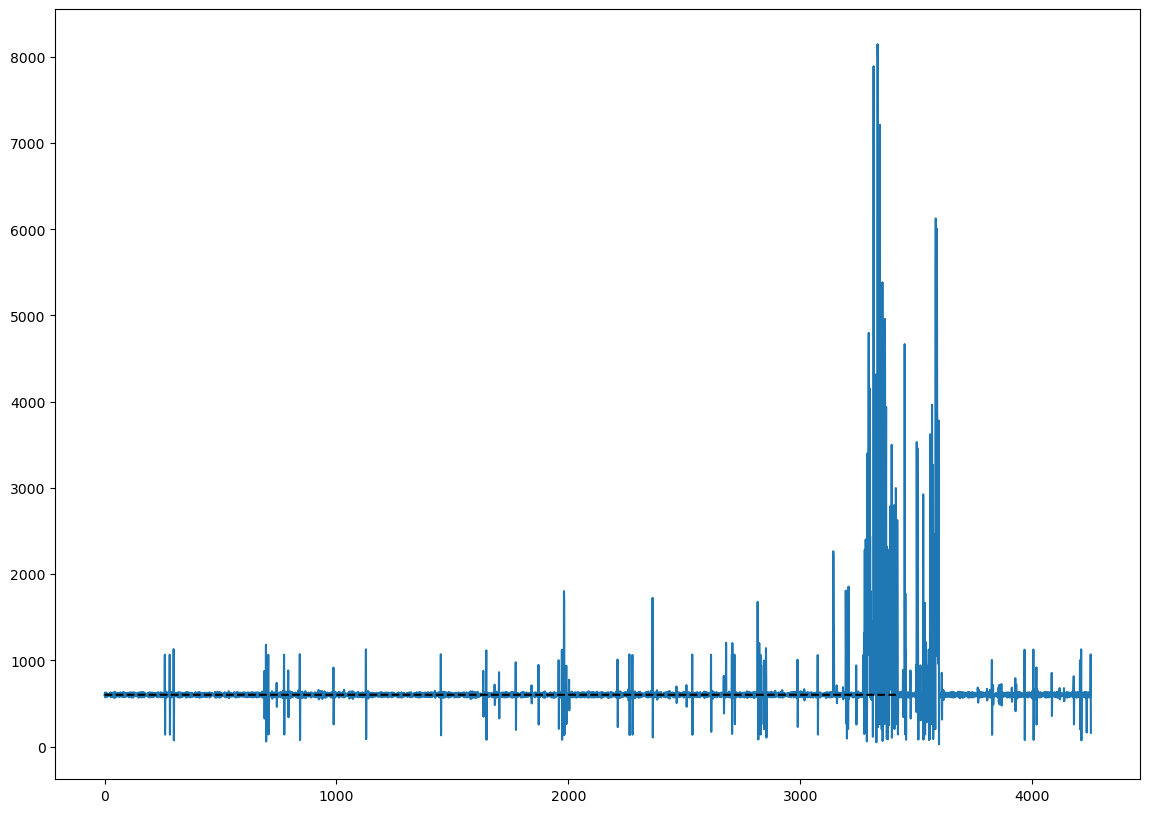

In [21]:
plt.figure(figsize=(14,10))
plt.plot(dt_drif_car001)
plt.plot(dt_drif_car001_IMEDEA, '--k')

# --> SOCIB non-regular time, changes a lot with time too!

# Plot of trajs.:

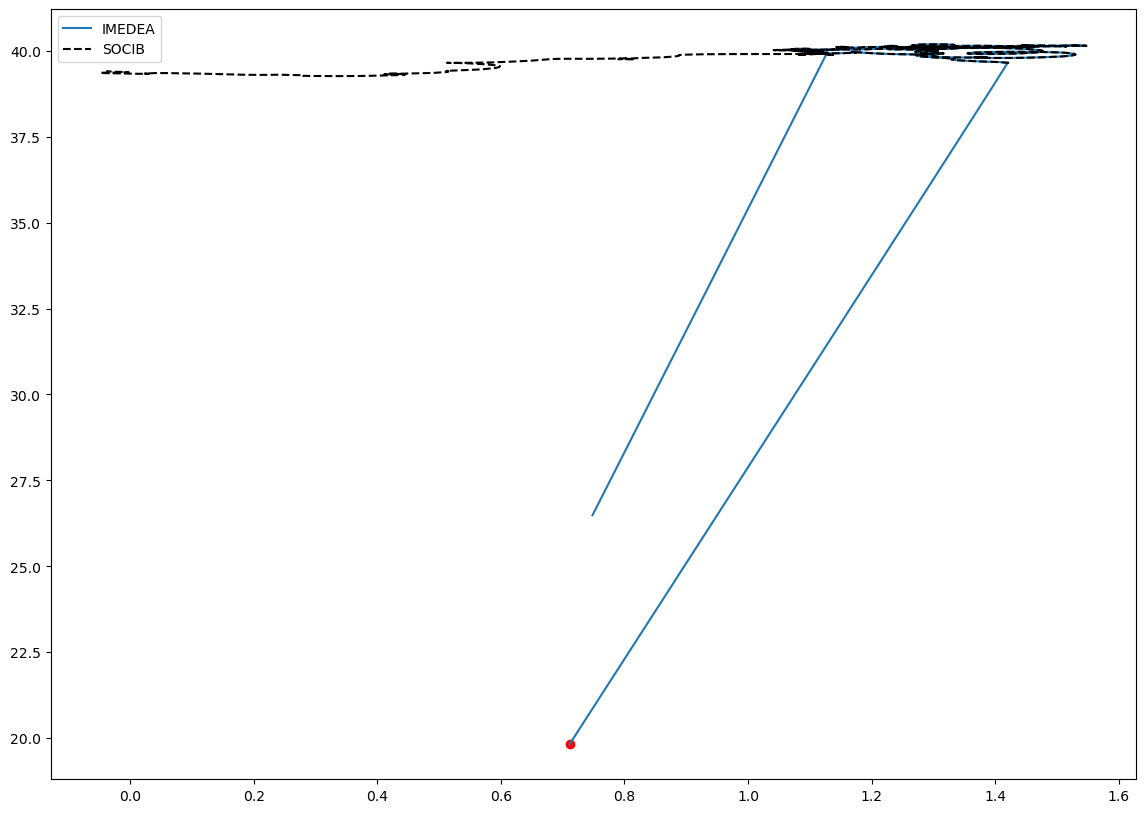

In [22]:
plt.figure(figsize=(14,10))
plt.plot(ds_car001_IMEDEA.LON, ds_car001_IMEDEA.LAT, label='IMEDEA')
plt.scatter(ds_car001_IMEDEA.LON[0], ds_car001_IMEDEA.LAT[0], c='r')
plt.plot(ds_car001.LON, ds_car001.LAT, '--k', label='SOCIB')
plt.legend()


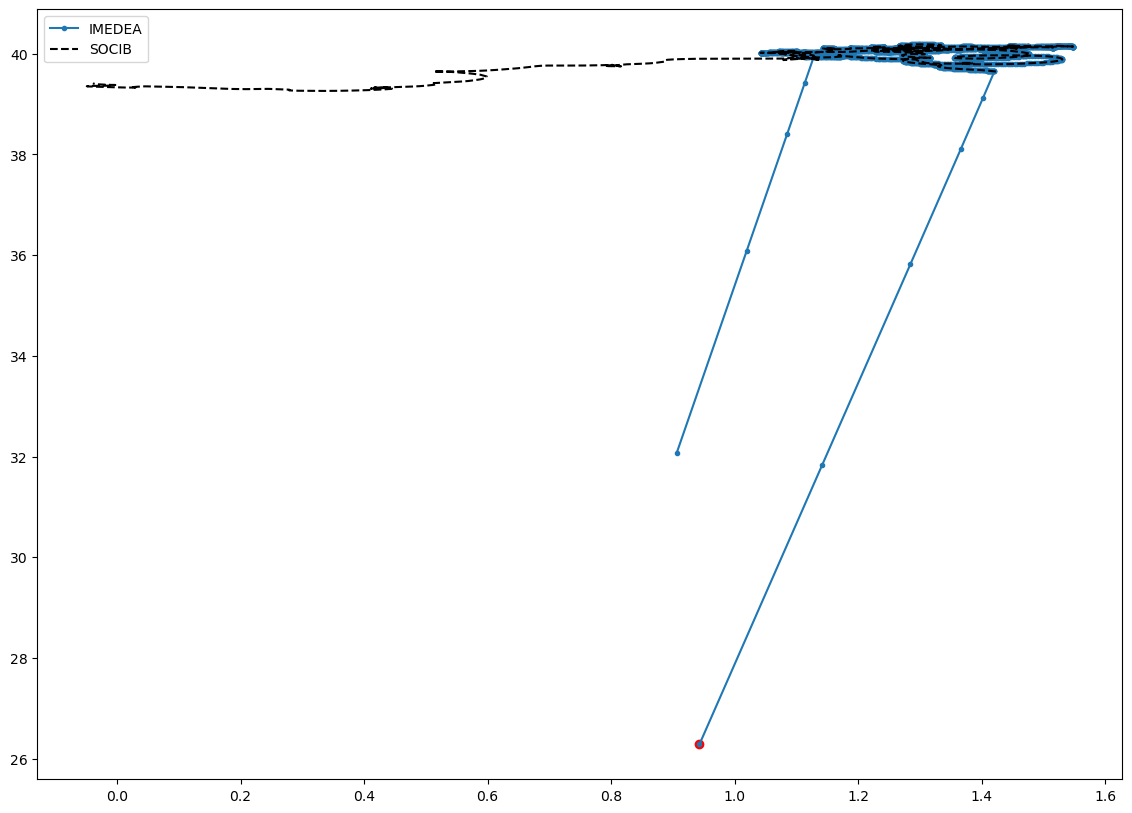

In [23]:
plt.figure(figsize=(14,10))
plt.plot(ds_car001_IMEDEA.LON[1:-1], ds_car001_IMEDEA.LAT[1:-1], '.-', label='IMEDEA')
plt.scatter(ds_car001_IMEDEA.LON[1], ds_car001_IMEDEA.LAT[1], c='r')
plt.plot(ds_car001.LON, ds_car001.LAT, '--k', label='SOCIB')
plt.legend()


# --> have to remove first and last 6 points (n/2 ; n = 12 in smoothing)

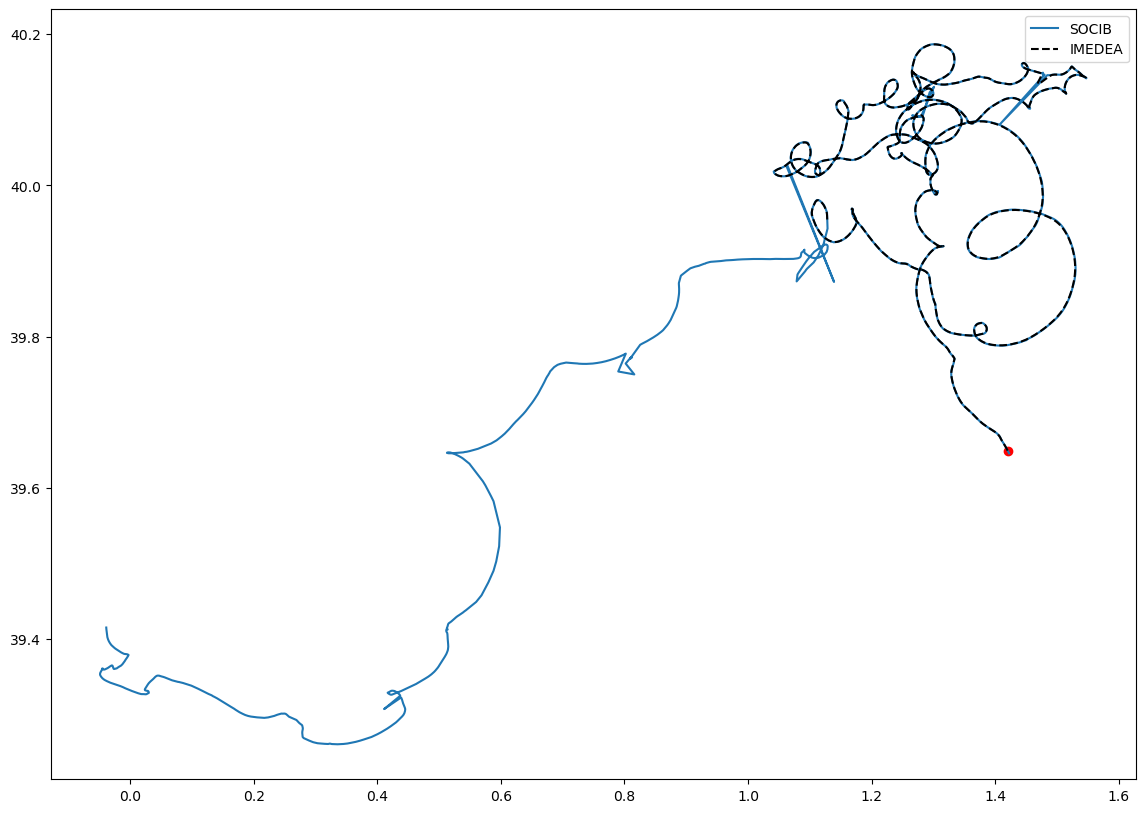

In [24]:
plt.figure(figsize=(14,10))
plt.plot(ds_car001.LON, ds_car001.LAT, label='SOCIB')
plt.plot(ds_car001_IMEDEA.LON[6:-6], ds_car001_IMEDEA.LAT[6:-6], '--k', label='IMEDEA')
plt.scatter(ds_car001_IMEDEA.LON[6], ds_car001_IMEDEA.LAT[6], c='r')
plt.legend()


# --> many spikes present in SOCIB's

# Zooming in:

(39.6, 40.2)

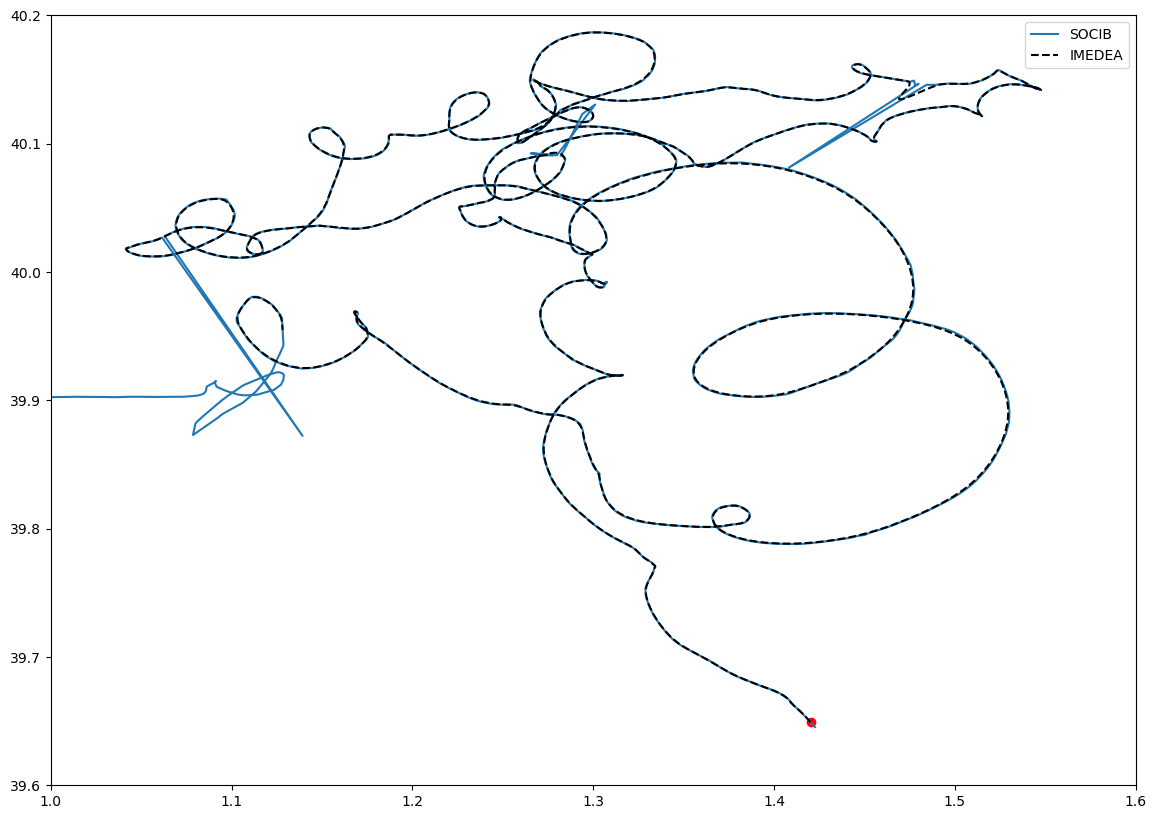

In [25]:
plt.figure(figsize=(14,10))
plt.plot(ds_car001.LON, ds_car001.LAT, label='SOCIB')
plt.plot(ds_car001_IMEDEA.LON[6:-6], ds_car001_IMEDEA.LAT[6:-6], '--k', label='IMEDEA')
plt.scatter(ds_car001_IMEDEA.LON[6], ds_car001_IMEDEA.LAT[6], c='r')
plt.legend()
plt.xlim([1., 1.6])
plt.ylim([39.6, 40.2])

# --> very similar
# --> top right peak we hav spike too

# Velocity comparison: 

In [16]:
abs_vel_car001_IMEDEA = (ds_car001_IMEDEA.U**2 + ds_car001_IMEDEA.V**2)**0.5 #np.sqrt


In [17]:
ds_car001.PLAT_SPEED_GR

<xarray.DataArray 'PLAT_SPEED_GR' (time: 4255)>
[4255 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 2023-04-26T10:16:51 ... 2023-05-28T19:14:18
    LAT      (time) float64 ...
    LON      (time) float64 ...
    DEPTH    float64 ...
Attributes:
    standard_name:        platform_speed_wrt_ground
    units:                m s-1
    ancillary_variables:  QC_PLAT_SPEED_GR
    original_units:       m s-1
    observation_type:     derived
    precision:            0.0001

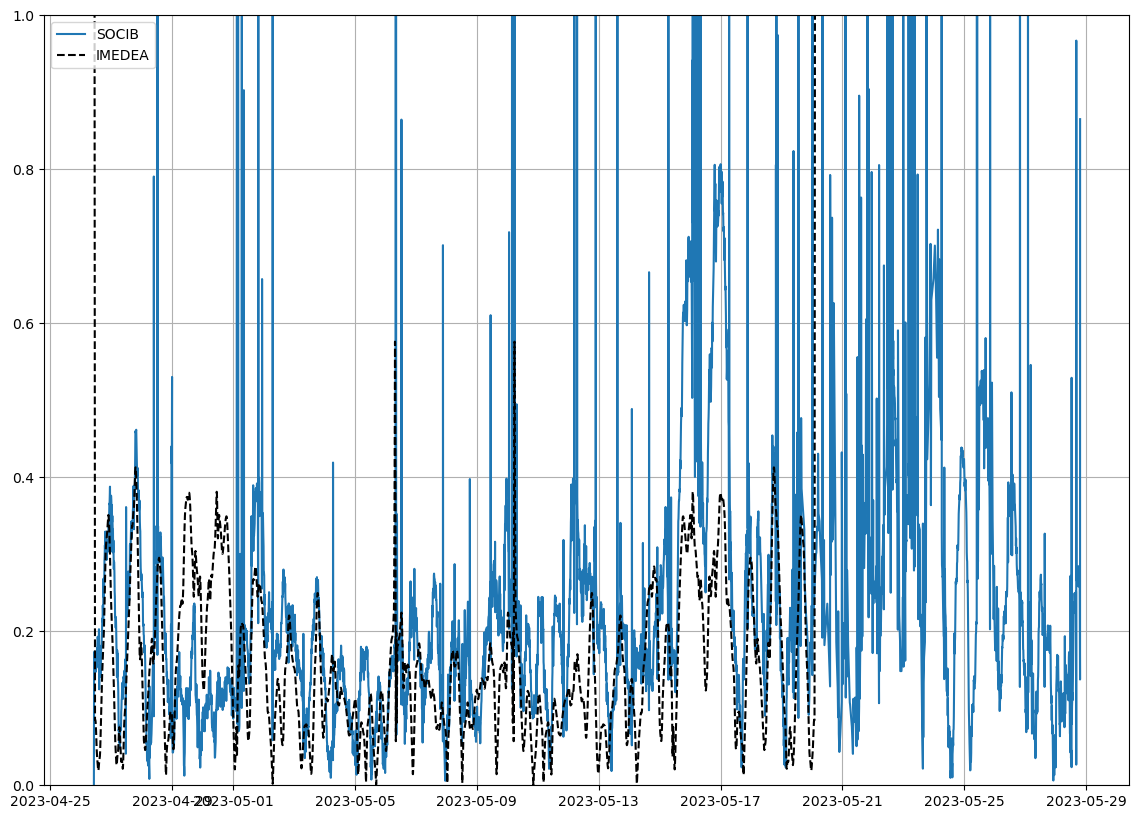

In [18]:
plt.figure(figsize=(14,10))
plt.plot(ds_car001.time, ds_car001.PLAT_SPEED_GR, label='SOCIB')
plt.plot(ds_car001_IMEDEA.time, abs_vel_car001_IMEDEA, '--k', label='IMEDEA')
plt.ylim([0,1])
plt.legend()
plt.grid()

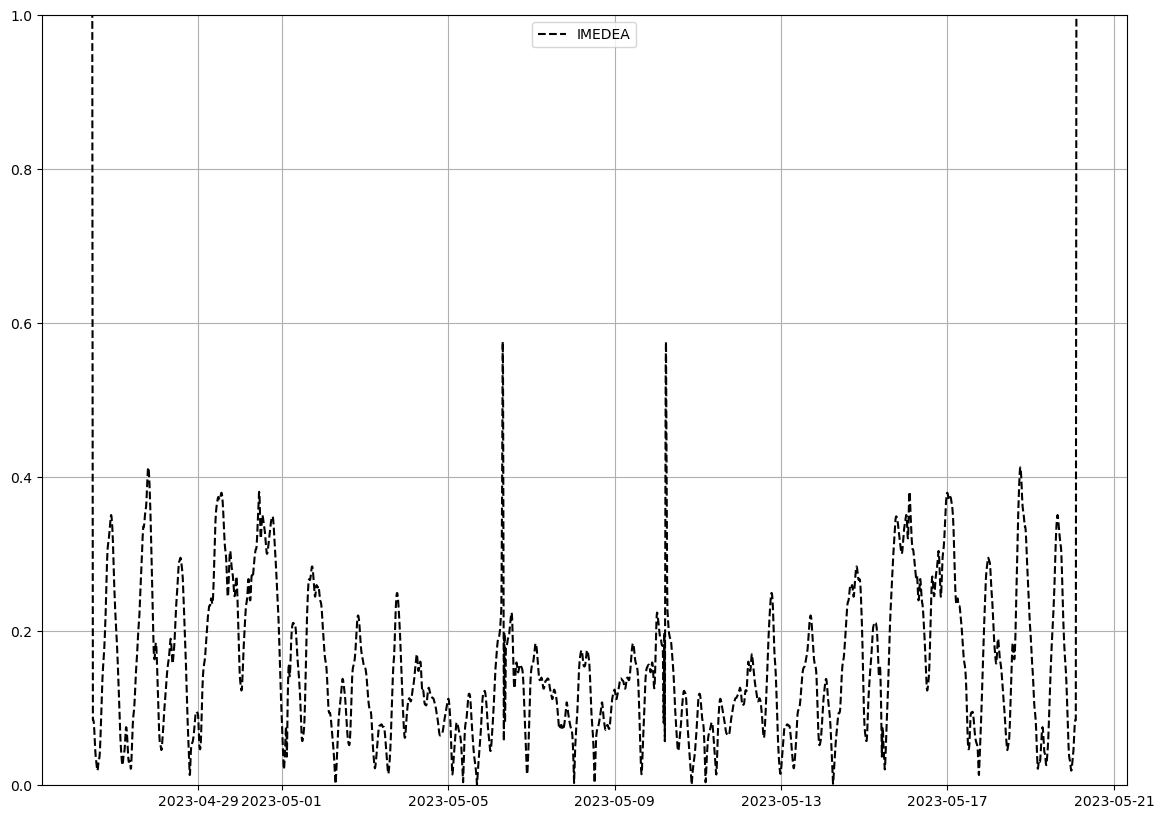

In [42]:
plt.figure(figsize=(14,10))
# plt.plot(ds_car001.time, ds_car001.PLAT_SPEED_GR, label='SOCIB')
plt.plot(ds_car001_IMEDEA.time, abs_vel_car001_IMEDEA, '--k', label='IMEDEA')
plt.ylim([0,1])
plt.legend()
plt.grid()

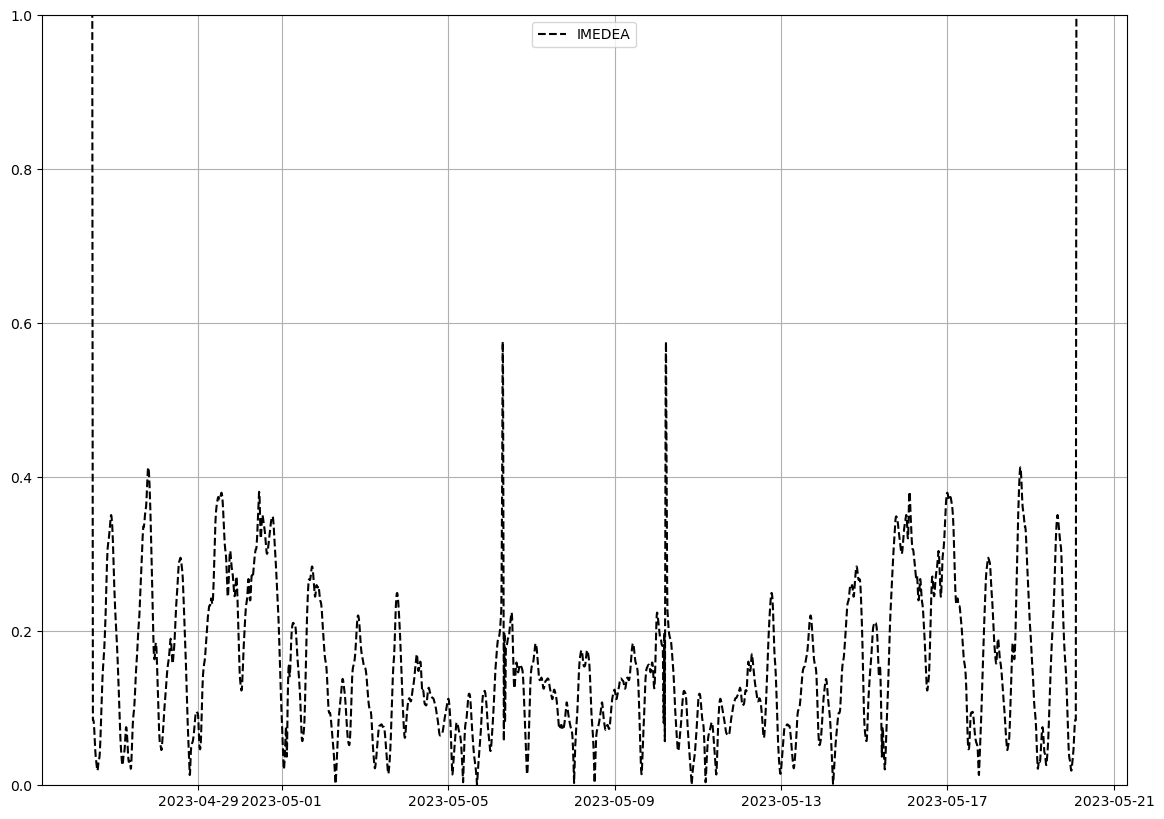

In [19]:
plt.figure(figsize=(14,10))
# plt.plot(ds_car001.time, ds_car001.PLAT_SPEED_GR, label='SOCIB')
plt.plot(ds_car001_IMEDEA.time, abs_vel_car001_IMEDEA, '--k', label='IMEDEA')
plt.ylim([0,1])
plt.legend()
plt.grid()

# --> weird black peaks in IMEDEA at beginning

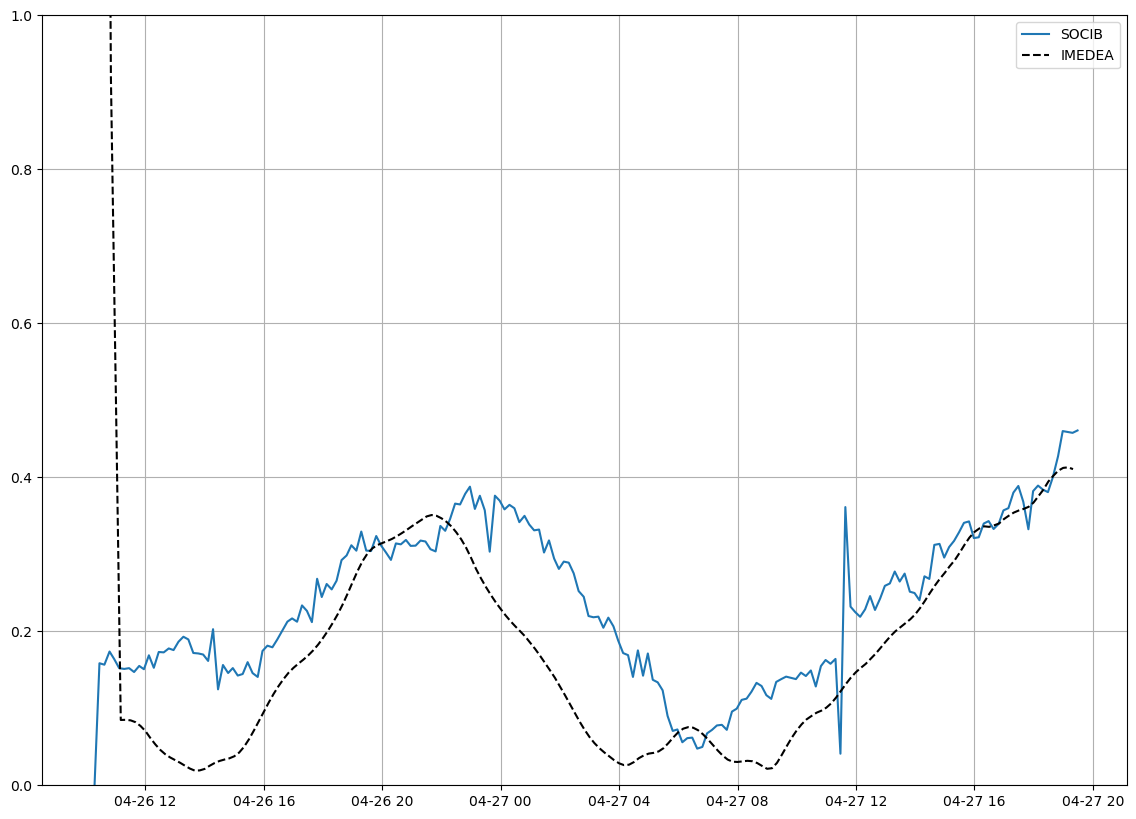

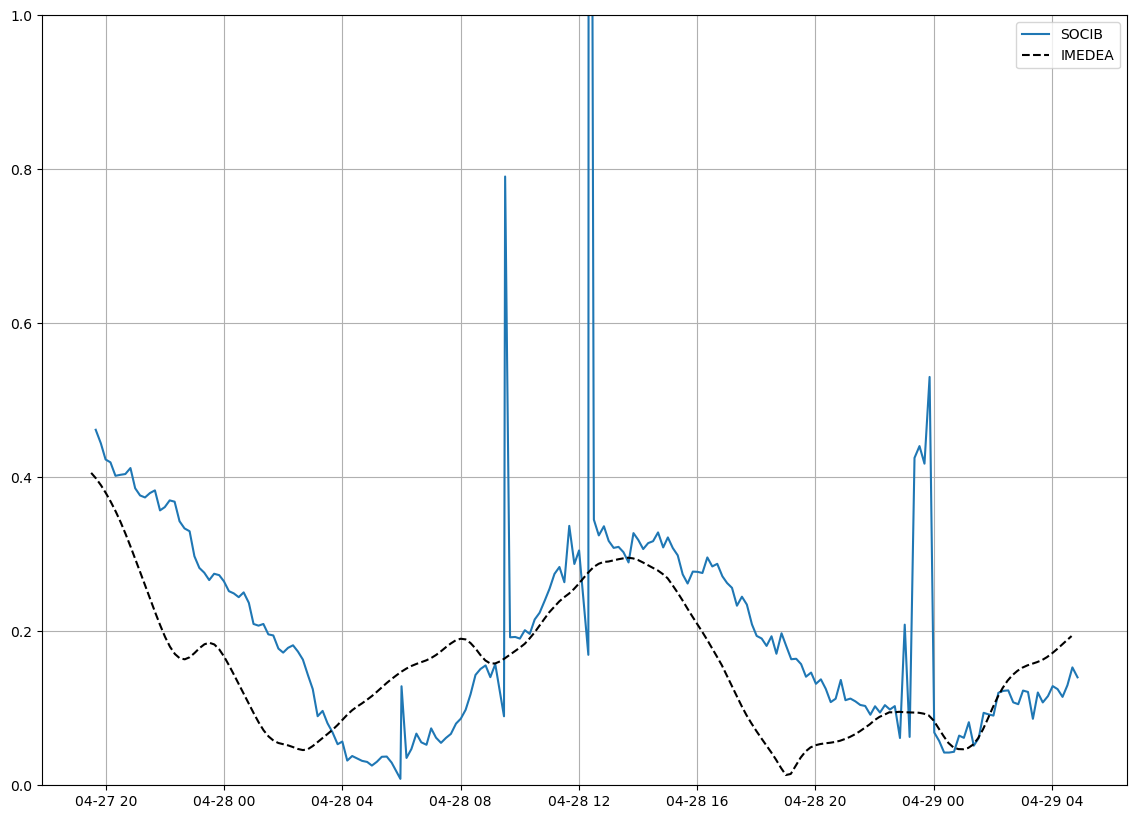

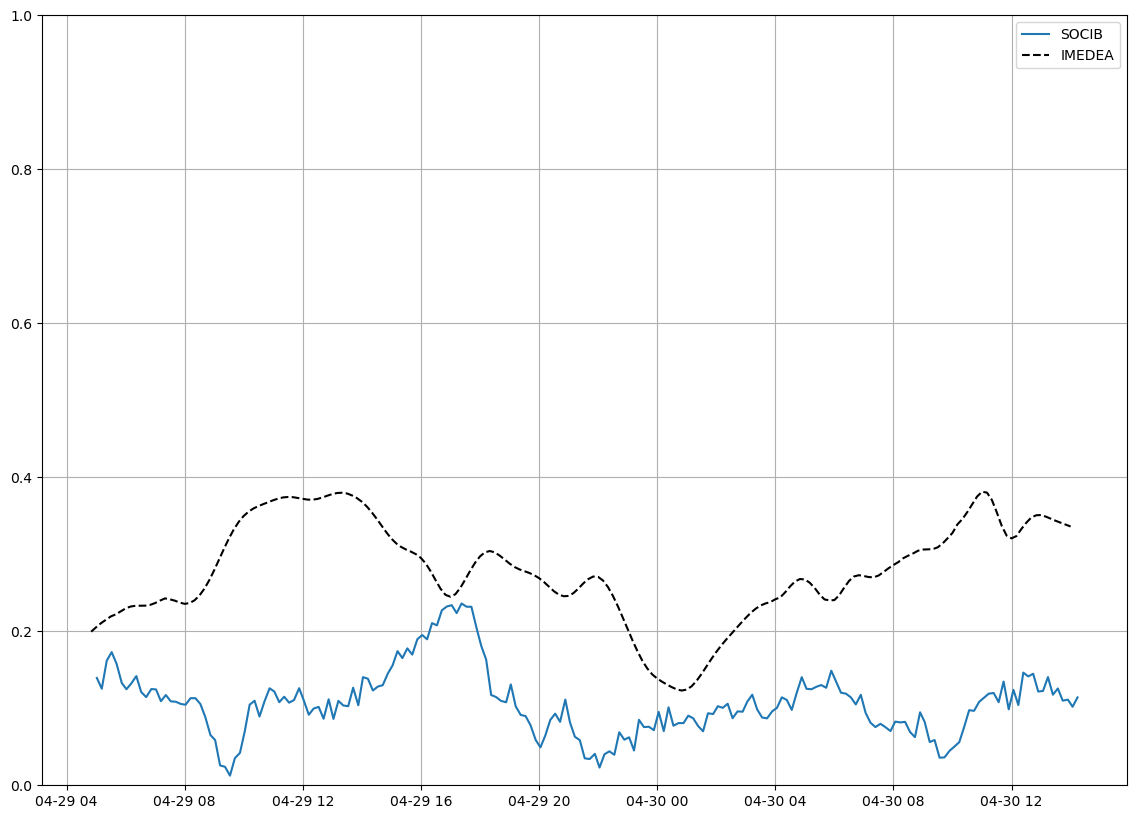

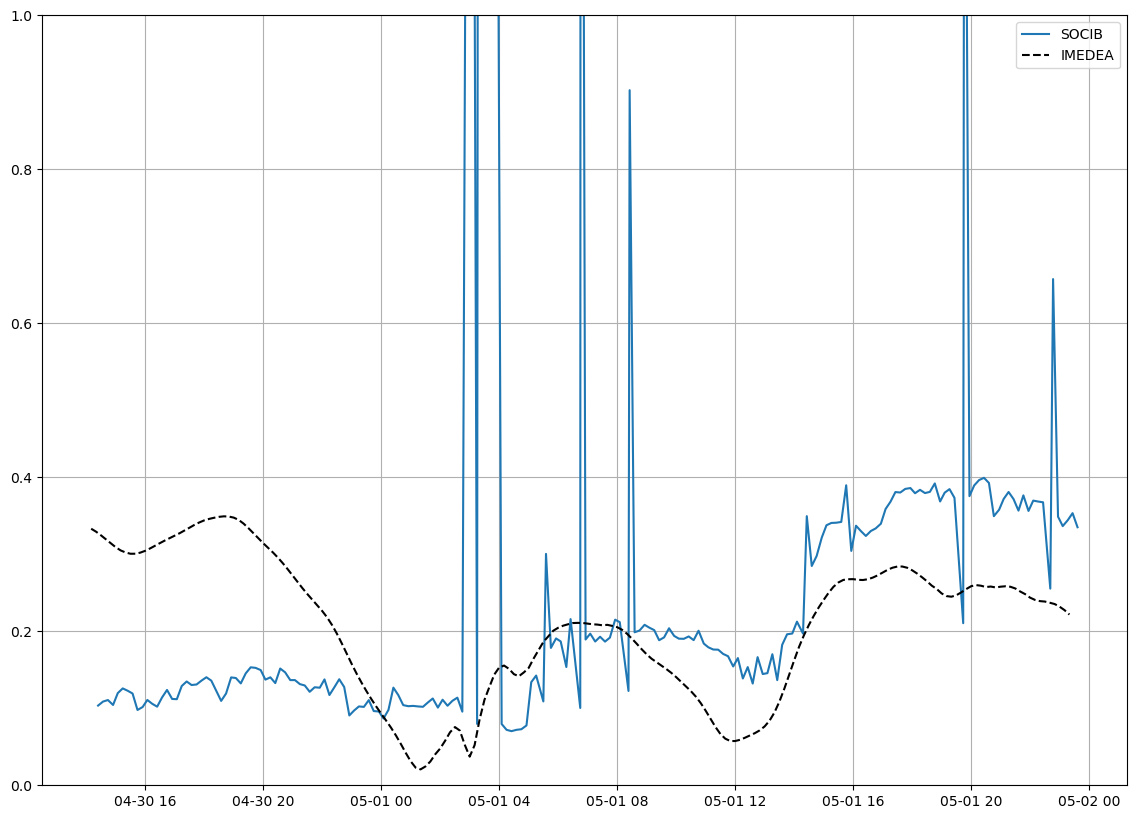

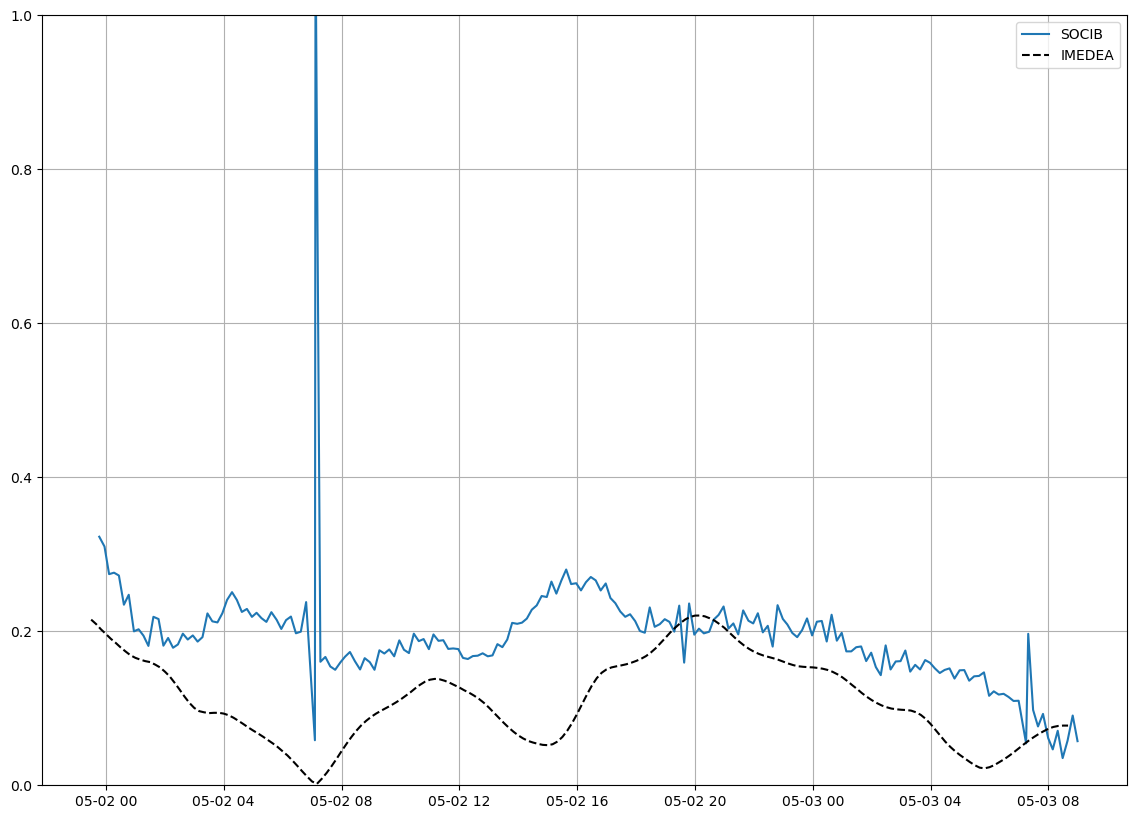

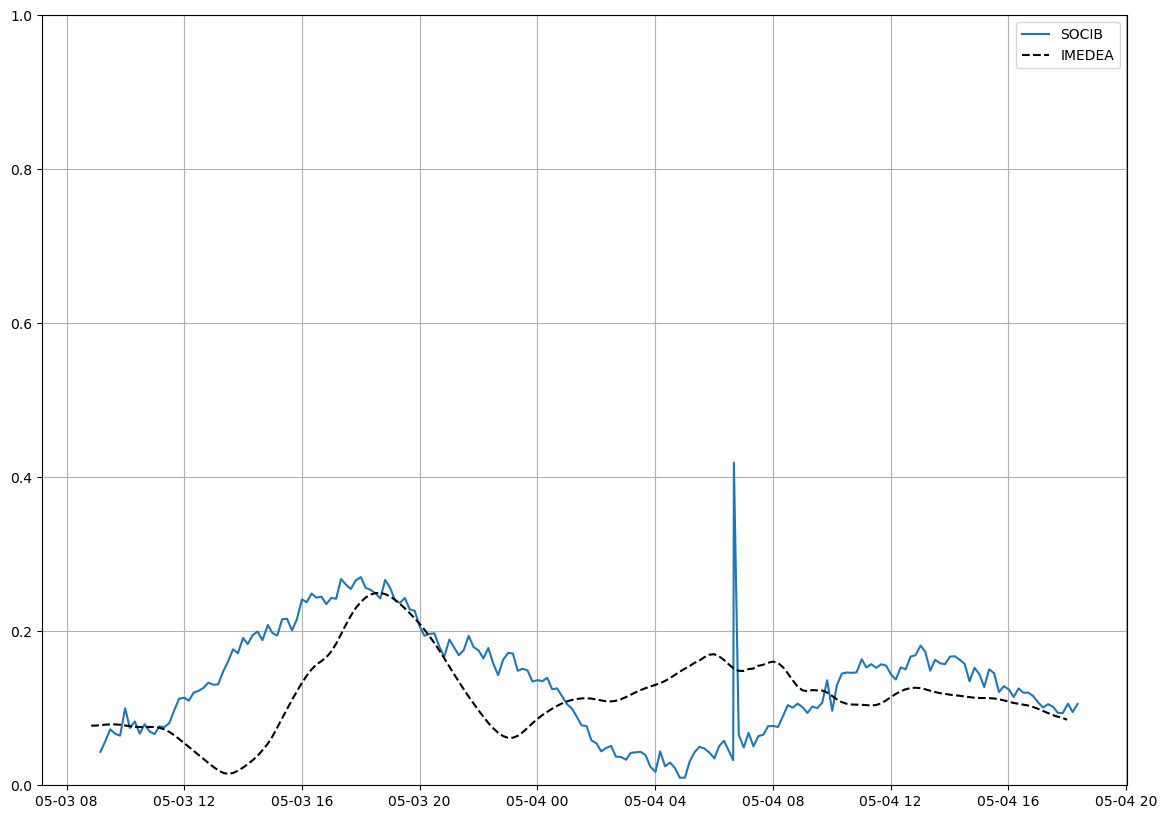

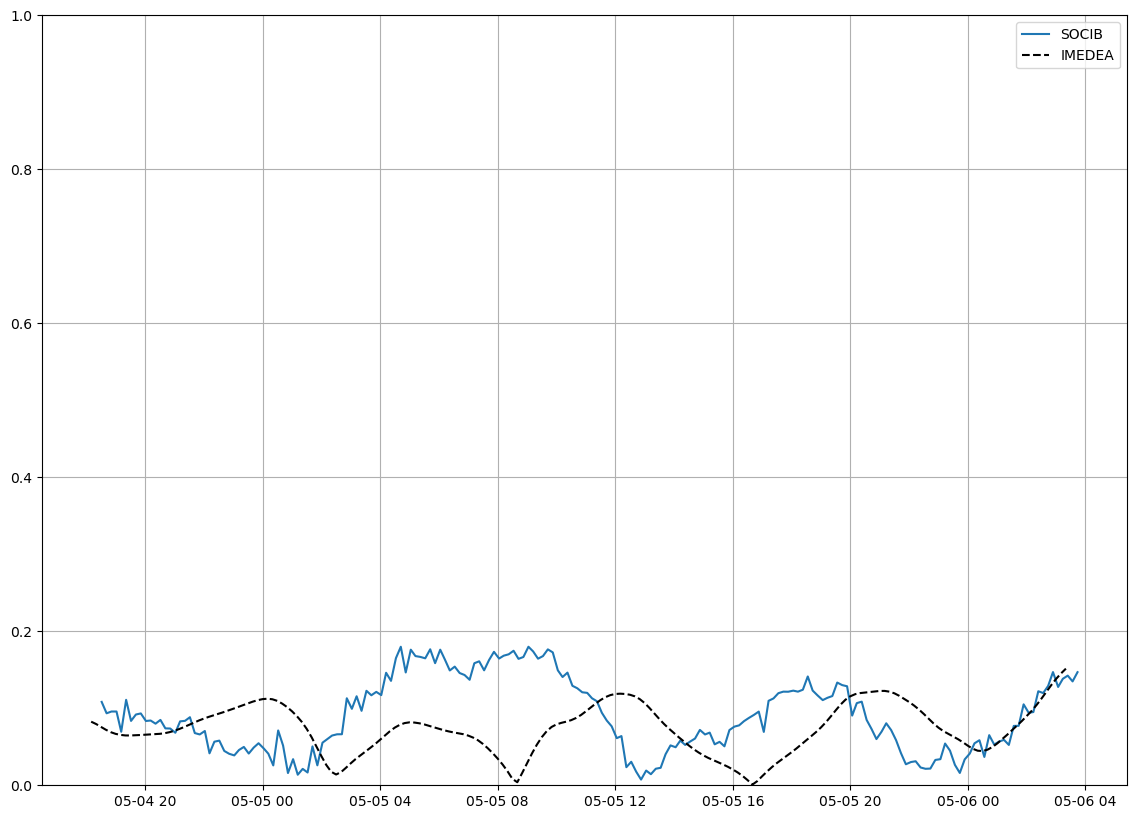

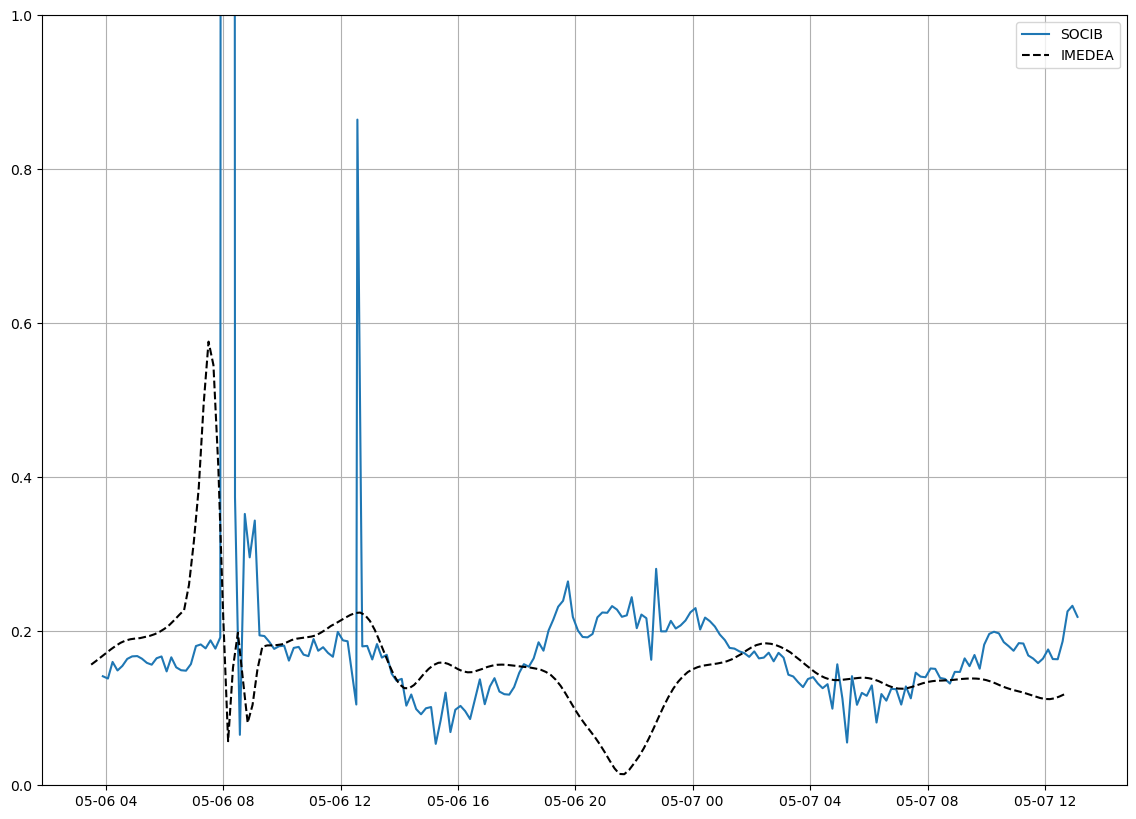

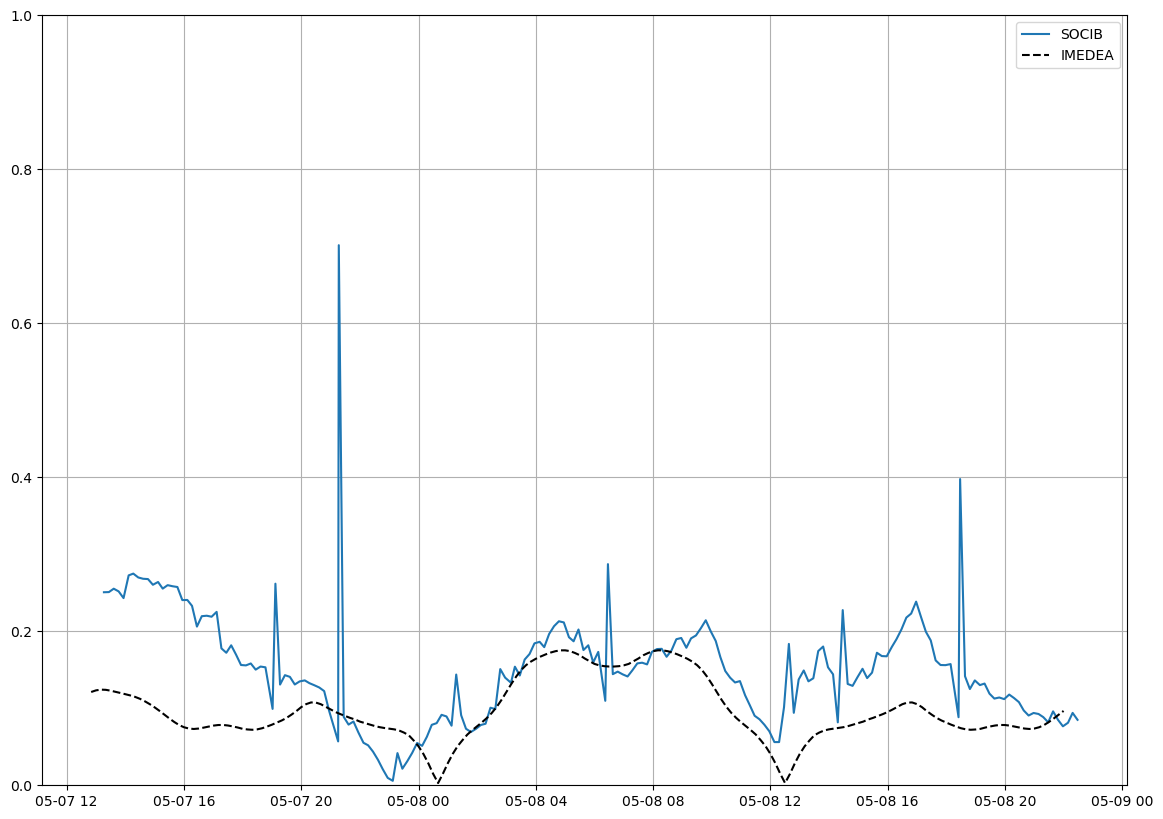

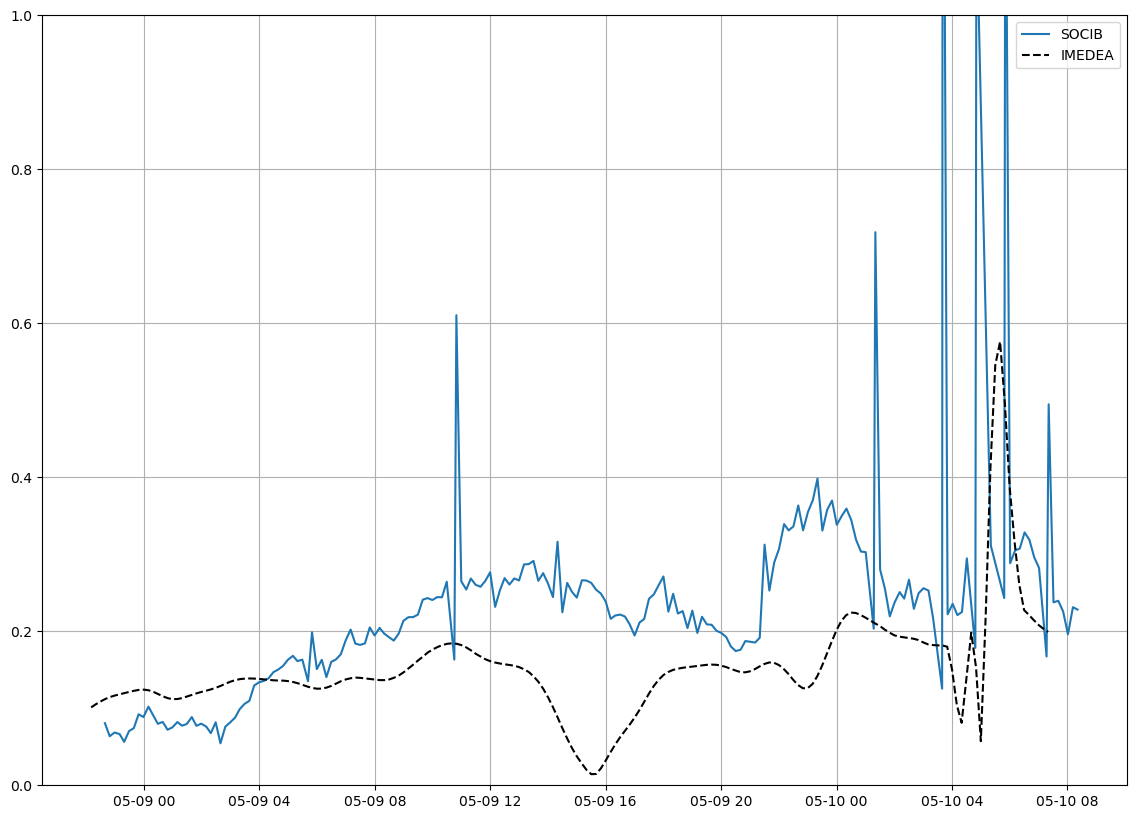

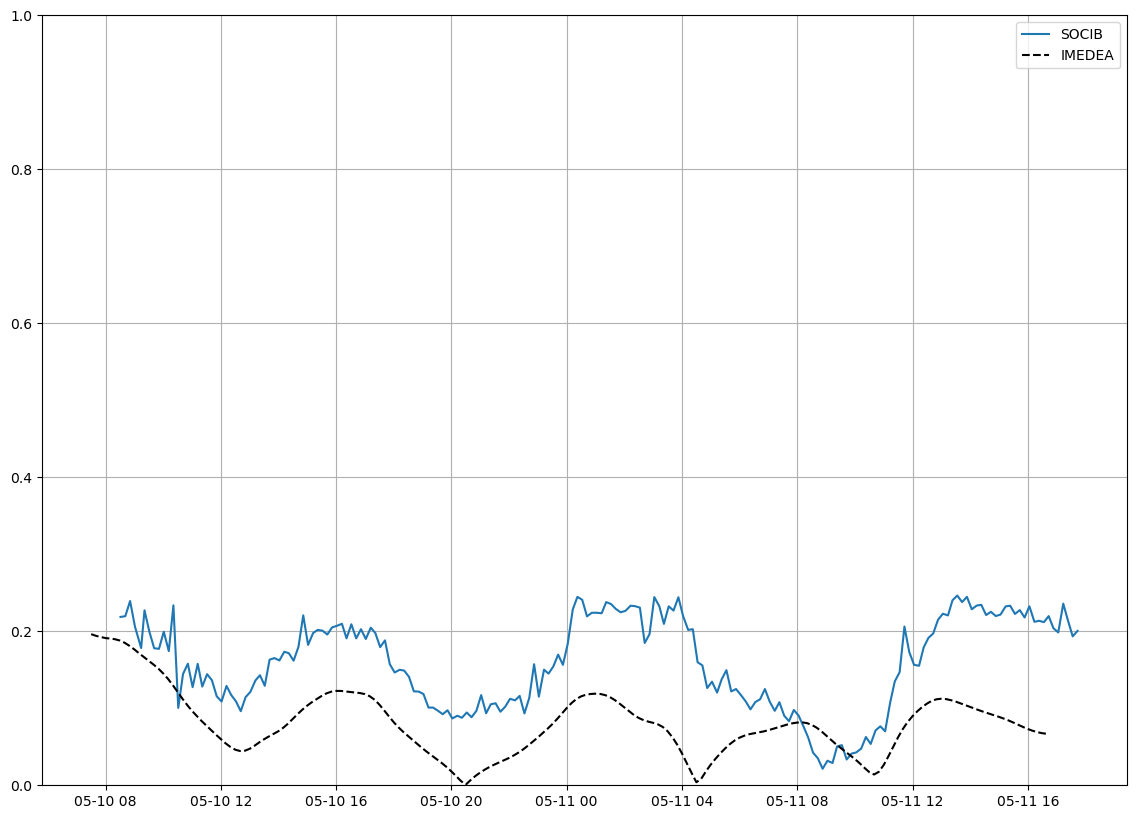

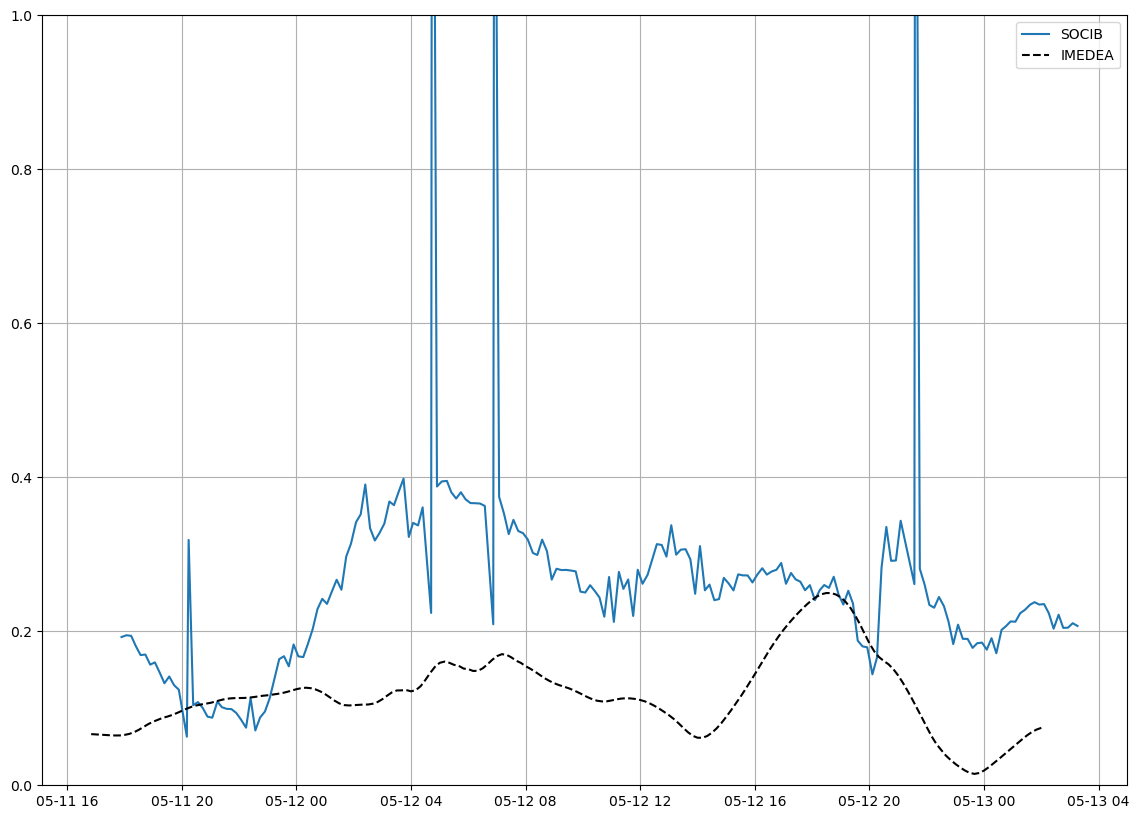

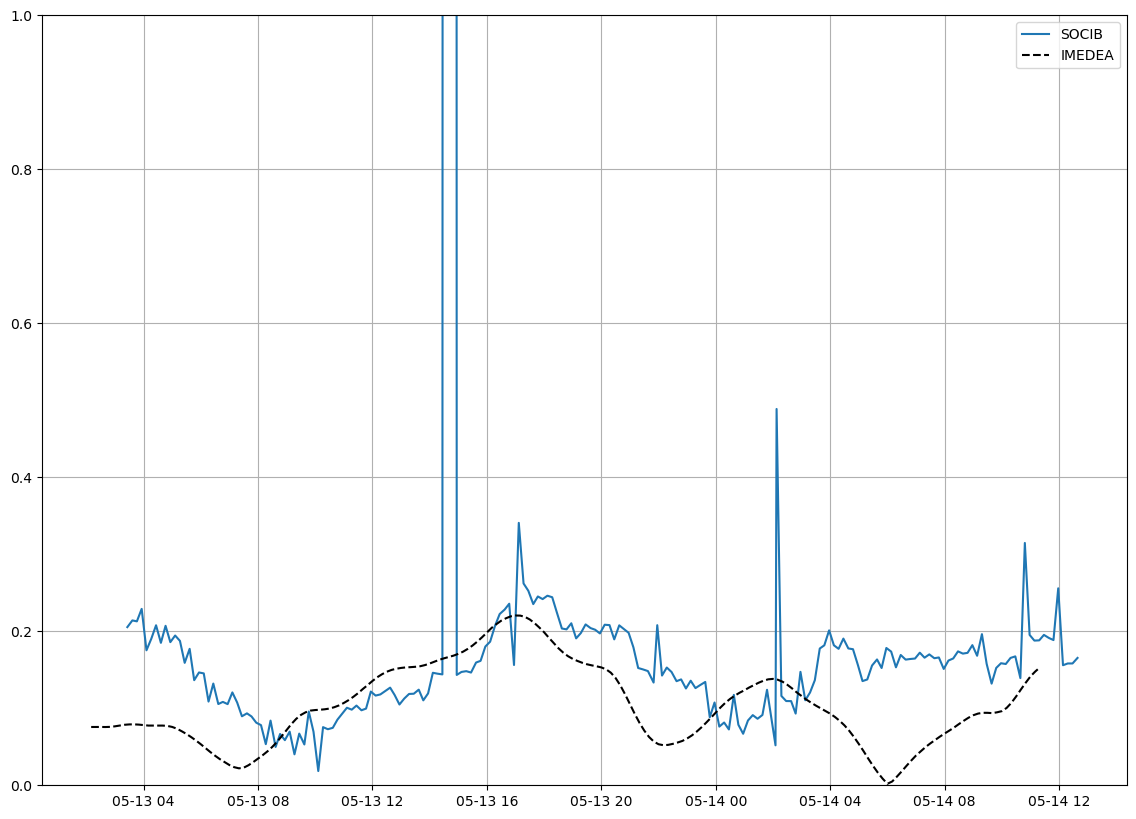

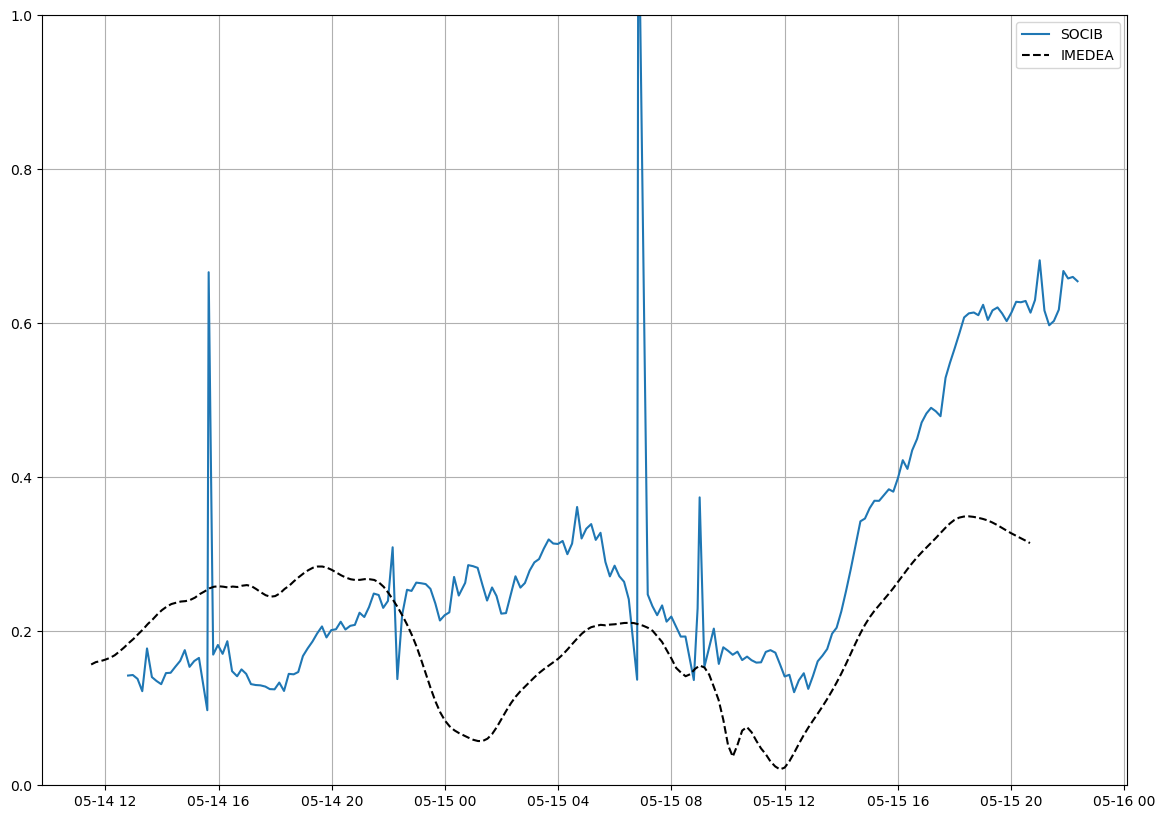

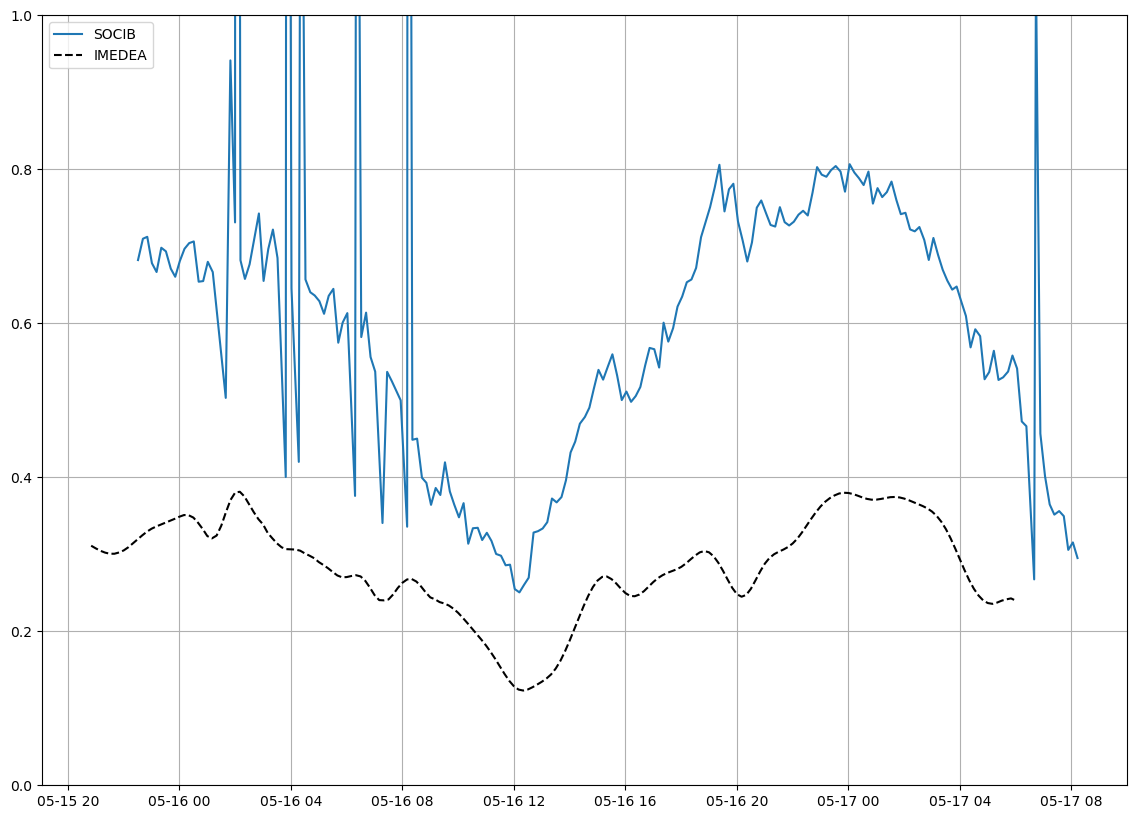

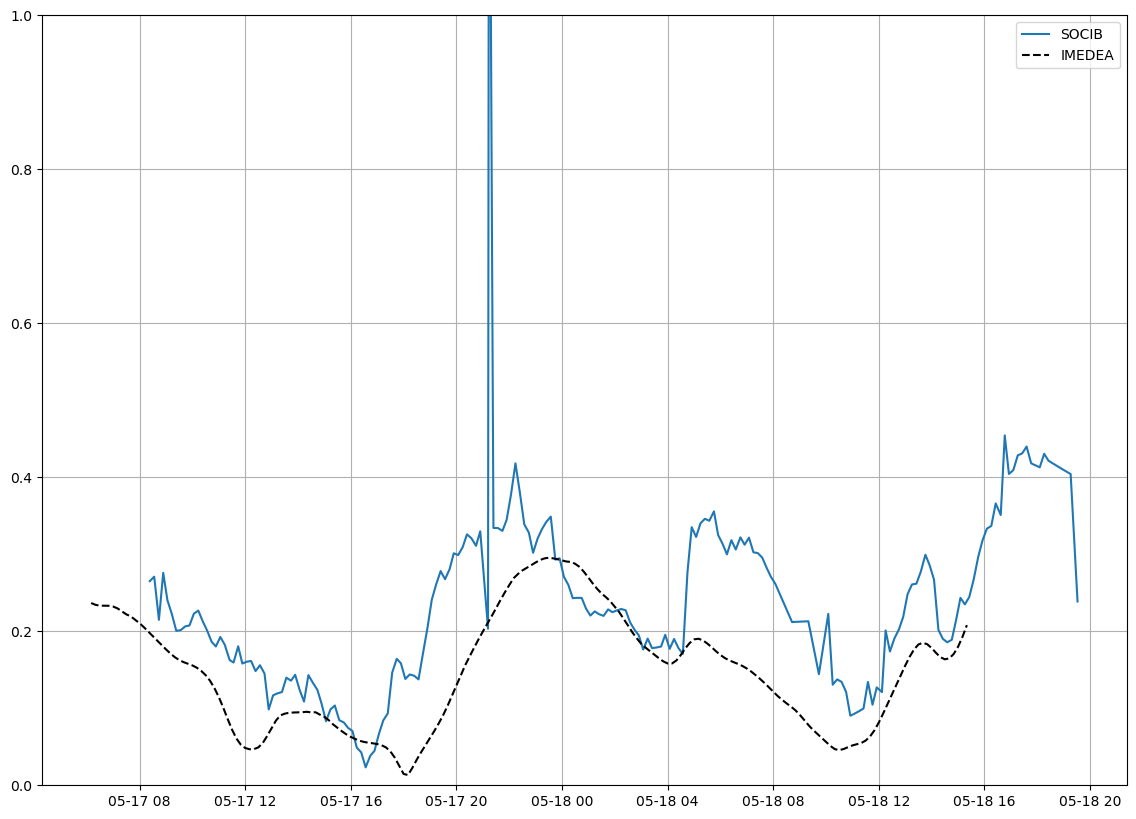

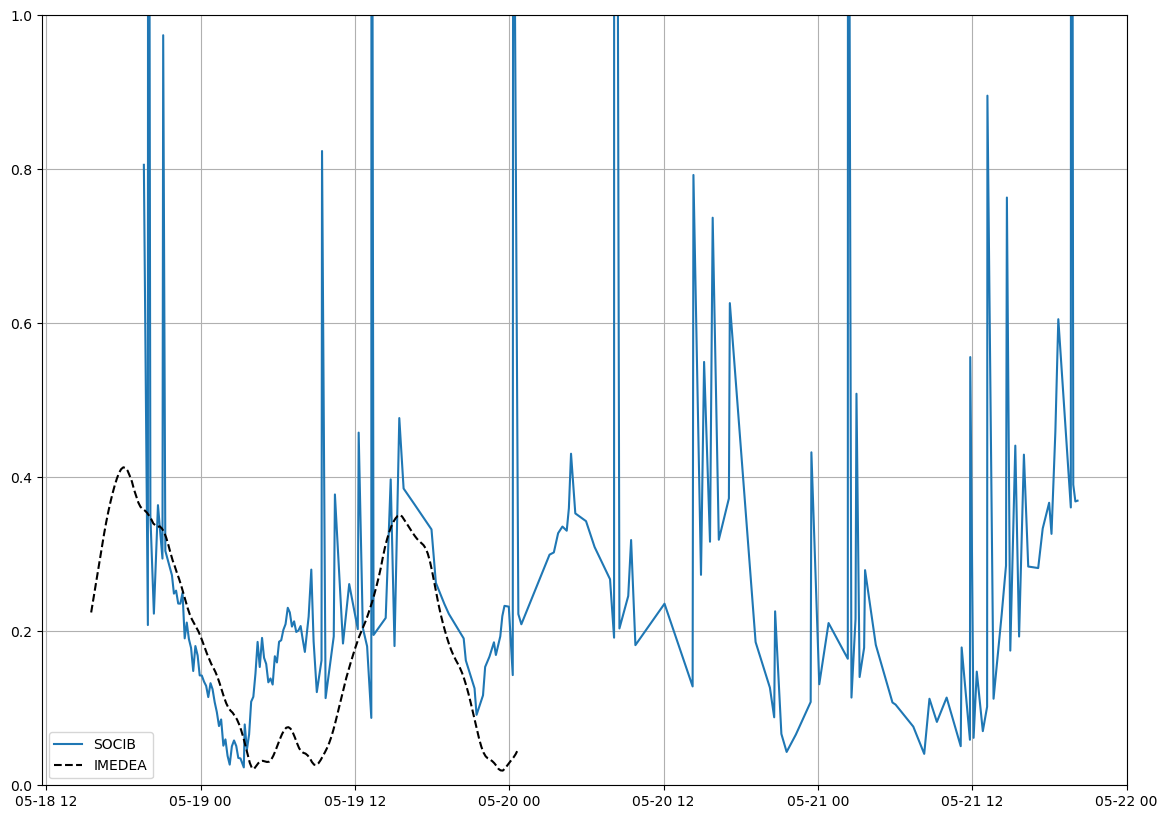

In [29]:
# to visualize data gaps:
for ii in range(0, int(np.floor(len(abs_vel_car001_IMEDEA)/200.))):
    plt.figure(figsize=(14,10))
    plt.plot(ds_car001.time[(ii*200):((ii+1)*200)], ds_car001.PLAT_SPEED_GR[(ii*200):((ii+1)*200)], label='SOCIB')
    plt.plot(ds_car001_IMEDEA.time[(ii*200):((ii+1)*200)], abs_vel_car001_IMEDEA[(ii*200):((ii+1)*200)], '--k', label='IMEDEA')
    plt.ylim([0,1])
    plt.legend()
    plt.grid()


# --> oh oh , nearly 0.2 m/s difference. Found some bugs , now better but still weird, some "frenazos"

# Possible sources:
- gilipollas
- smoothing
- velocity calculation (BCs, forward (SOCIB) diferenciadas centradas (IMEDEA) 

# Dudas para Lara:

QC_drifters... .pdf

* Spike detection: 
    * done on lon, lat, vel or acc?
    * what do they do with detections? flag only?

* gradient: y que pasa?

* stationary: y que pasa?

Only add flags and speed from L0 to L1? Take account flags for speed calculation? CARTHE no direction, HEREON yes?

## Speed calculation:
* both use use haversine
* SOCIB: vel calculated backward: vel(t2) = dist(t2-t1) / (t2-t1)
* BCs: t1 = 0 (SOCIB); BC: t1 and tn = nan (IMEDEA)

## Checking if we actually have nans in vels. :

In [30]:
ds_car001_IMEDEA.U[0].values

array(16.05007403)

# --> no, after smoothing nan we had before, not there anymore, so have to addBCs like Dani had before

In [31]:
abs_vel_car001_IMEDEA[0:200].min()

<xarray.DataArray ()>
array(0.01902507)
Coordinates:
    DEPTH    float64 0.6

In [33]:
ds_car001.PLAT_SPEED_GR[1:200].min()

<xarray.DataArray 'PLAT_SPEED_GR' ()>
array(0.041)
Coordinates:
    DEPTH    float64 ...

# --> we reach smaller min...

# Plotting first 200 points traj:

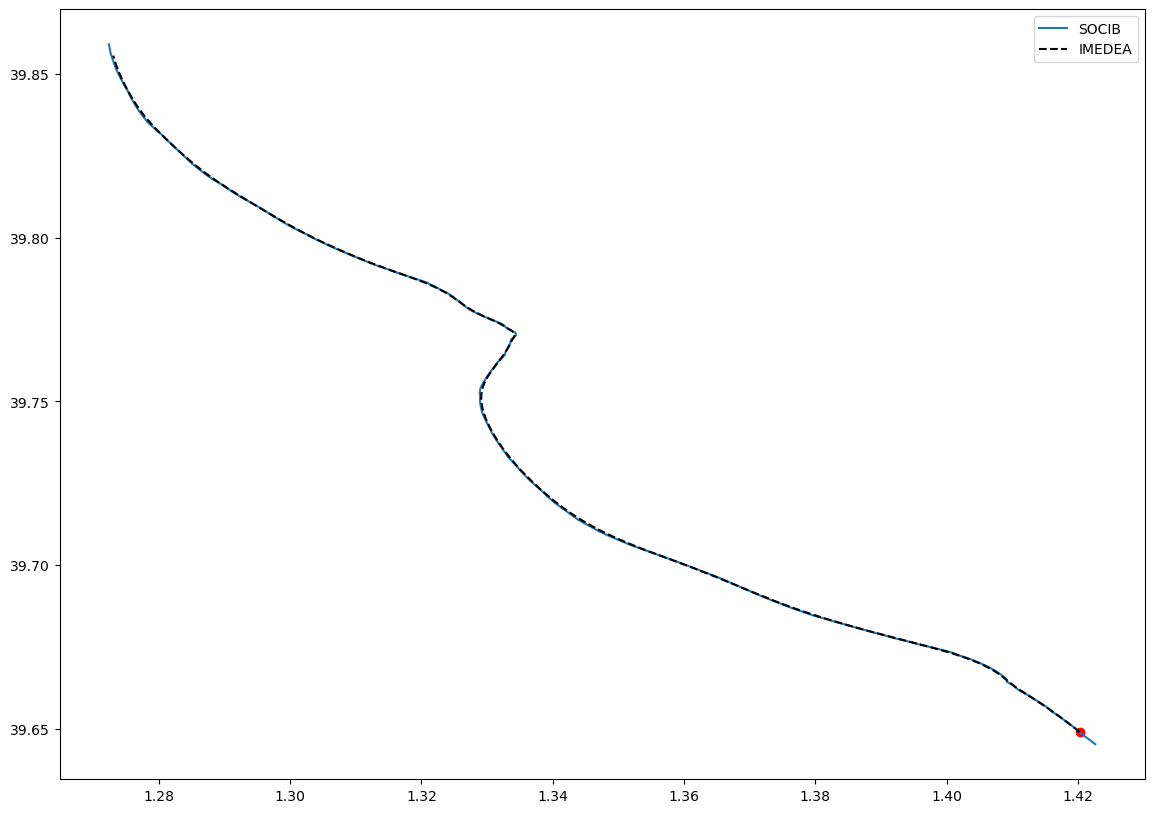

In [34]:
plt.figure(figsize=(14,10))
plt.plot(ds_car001.LON[0:200], ds_car001.LAT[0:200], label='SOCIB')
plt.plot(ds_car001_IMEDEA.LON[6:200], ds_car001_IMEDEA.LAT[6:200], '--k', label='IMEDEA')
plt.scatter(ds_car001_IMEDEA.LON[6], ds_car001_IMEDEA.LAT[6], c='r')
plt.legend()
# plt.xlim([1., 1.6])
# plt.ylim([39.6, 40.2])

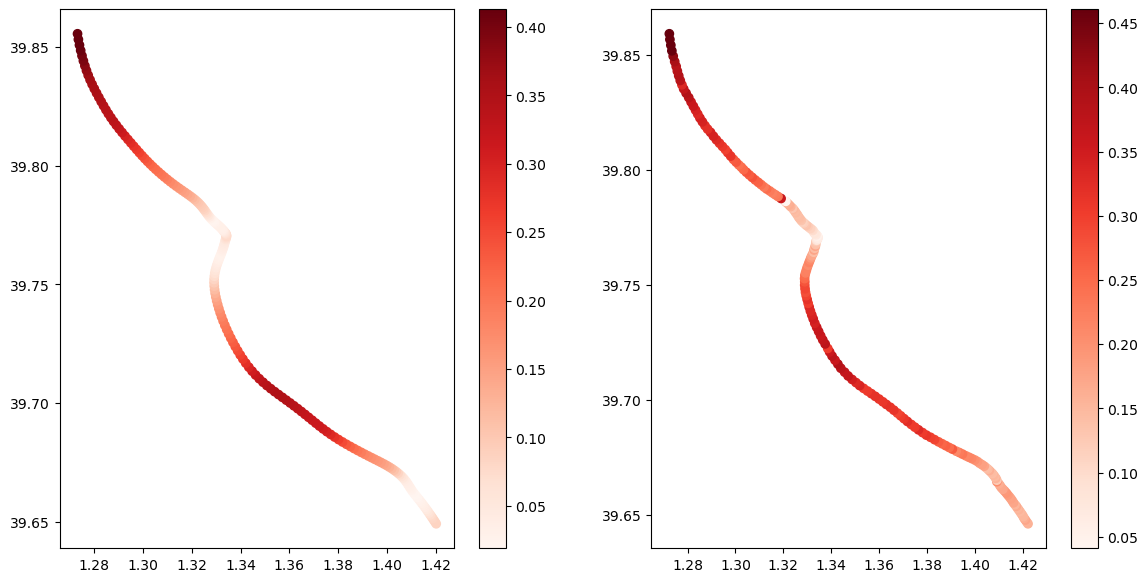

In [35]:
plt.figure(figsize=(14,7))
plt.subplot(121)
plt.scatter(ds_car001_IMEDEA.LON[6:200], ds_car001_IMEDEA.LAT[6:200], c=abs_vel_car001_IMEDEA[6:200], cmap='Reds')
plt.colorbar()
# ds_car001.PLAT_SPEED_GR[1:200].min()

plt.subplot(122)
plt.scatter(ds_car001.LON[1:200], ds_car001.LAT[1:200], c=ds_car001.PLAT_SPEED_GR[1:200], cmap='Reds')
plt.colorbar()
# ds_car001.PLAT_SPEED_GR[1:200].min()


# 
## Before: --> makes more sense SOCIB's (slow down in crve not accelerate, and now low speed in "la recta")
## After first debugs, now slow downs coincide but still differences when plotting abs_vel time series

# Plotting lon and lat time series:

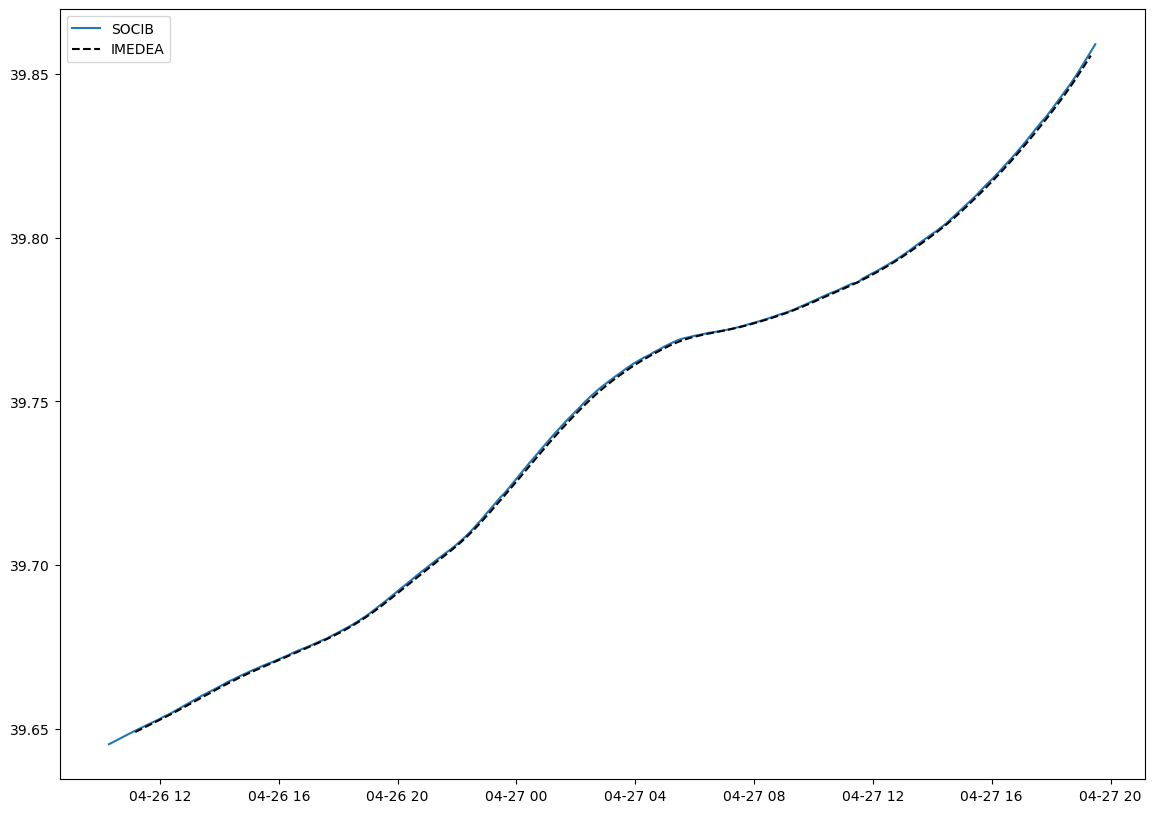

In [36]:
plt.figure(figsize=(14,10))
plt.plot(ds_car001.time[0:200], ds_car001.LAT[0:200], label='SOCIB')
plt.plot(ds_car001_IMEDEA.time[6:200], ds_car001_IMEDEA.LAT[6:200], '--k', label='IMEDEA')
plt.legend()
# plt.xlim([1., 1.6])
# plt.ylim([39.6, 40.2])

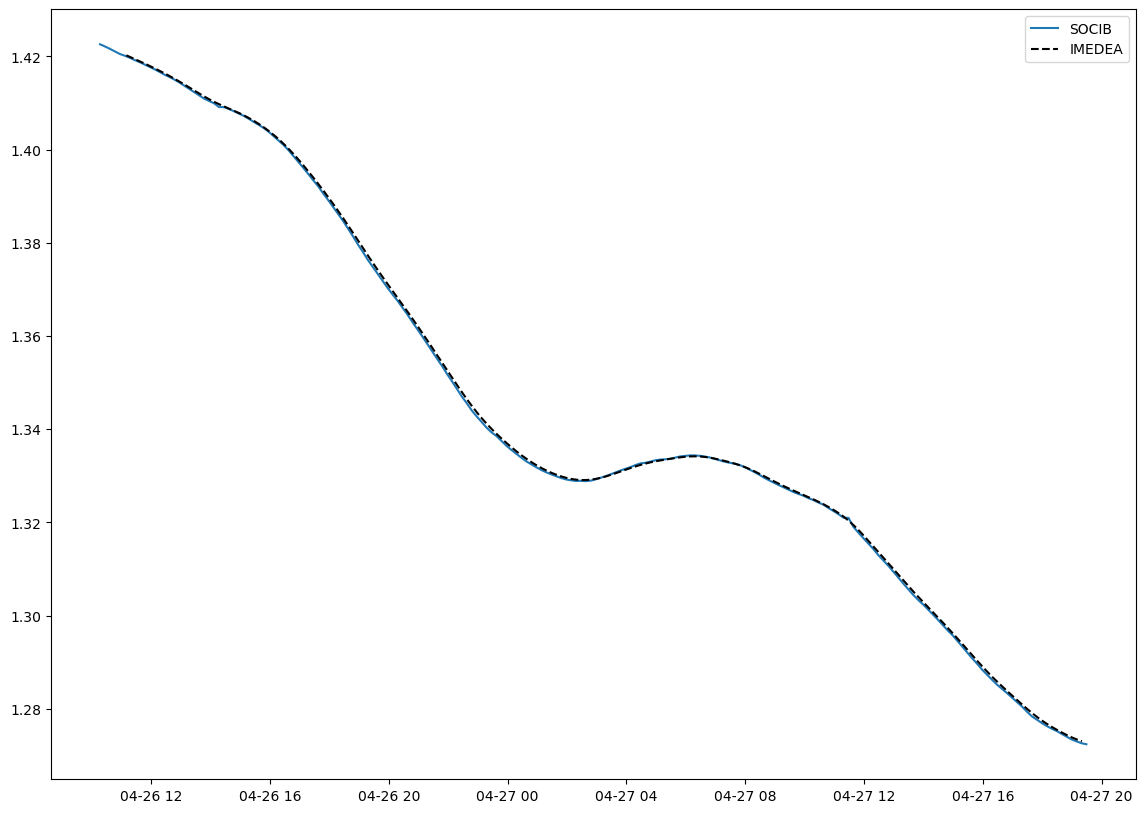

In [37]:
plt.figure(figsize=(14,10))
plt.plot(ds_car001.time[0:200], ds_car001.LON[0:200], label='SOCIB')
plt.plot(ds_car001_IMEDEA.time[6:200], ds_car001_IMEDEA.LON[6:200], '--k', label='IMEDEA')
plt.legend()
# plt.xlim([1., 1.6])
# plt.ylim([39.6, 40.2])

0


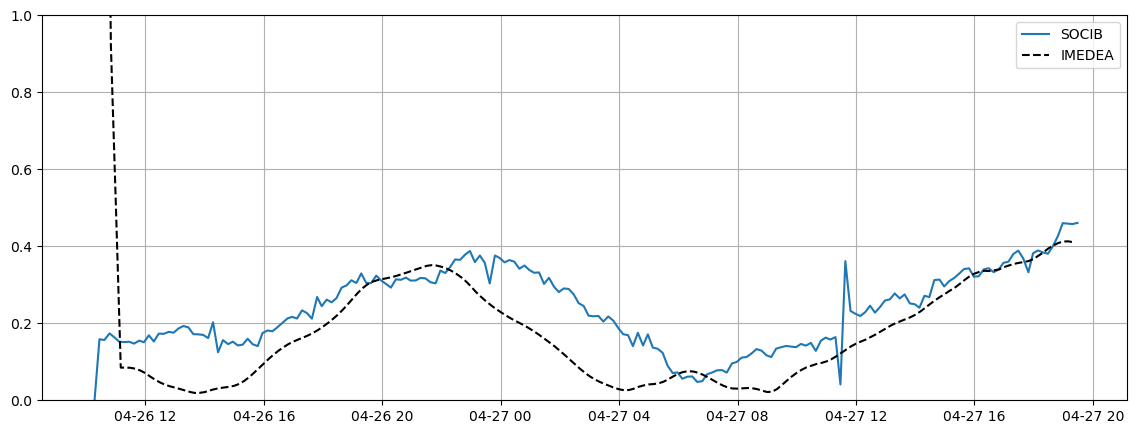

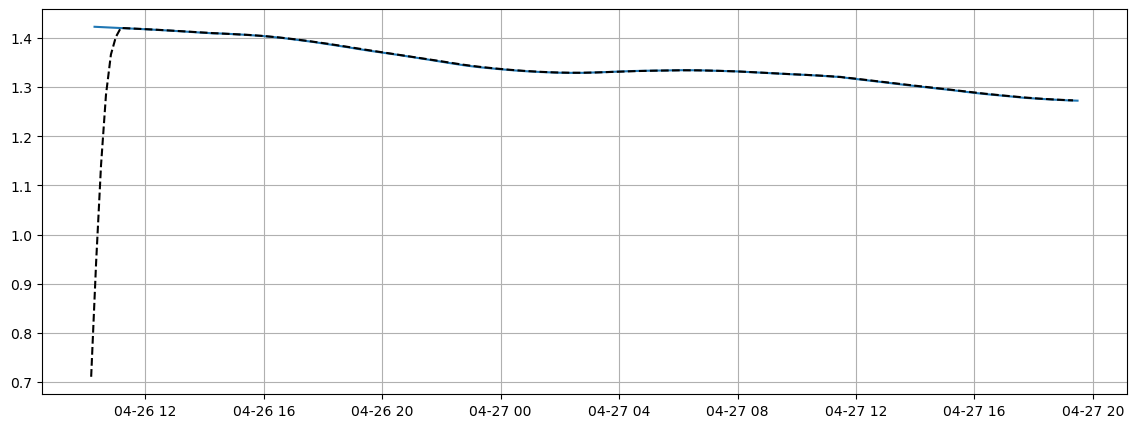

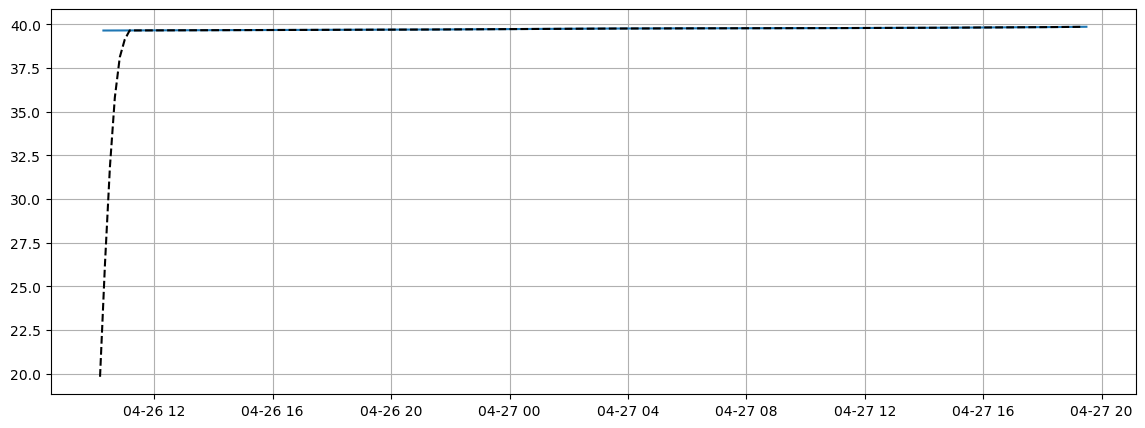

1


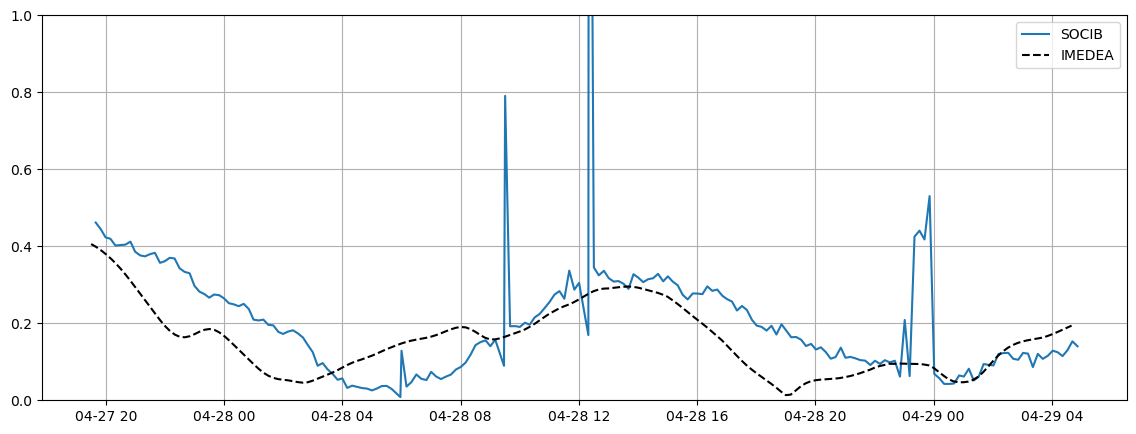

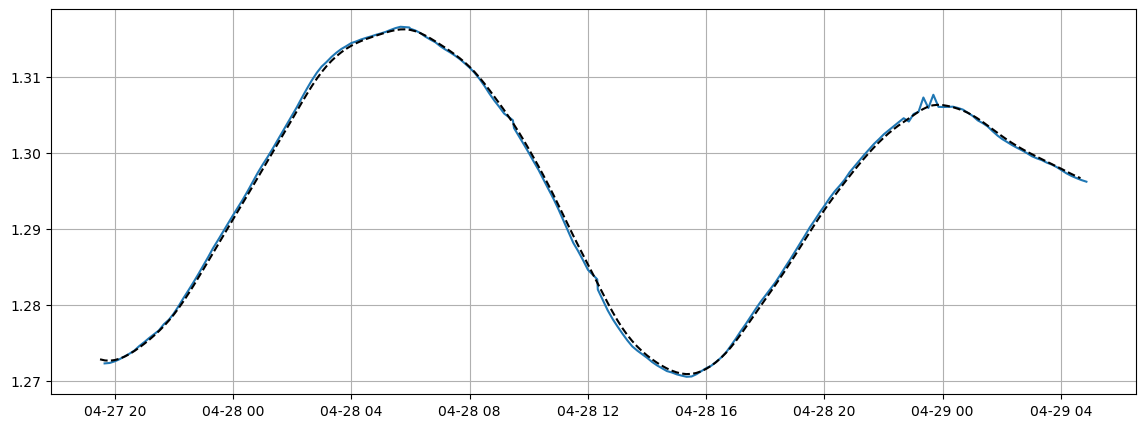

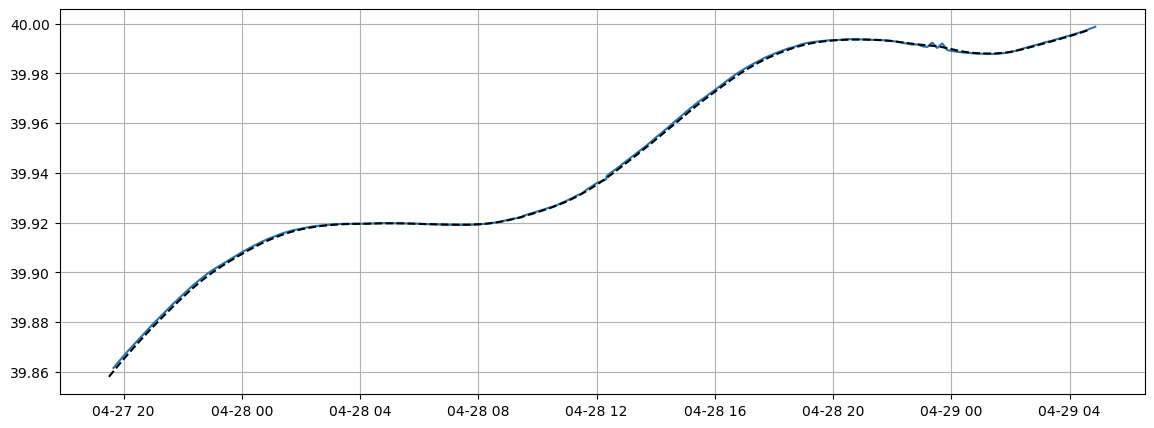

2


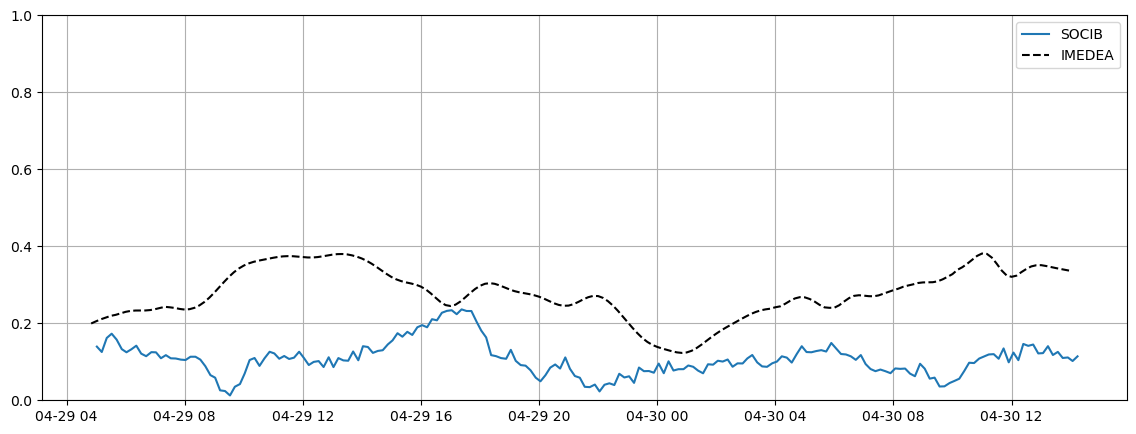

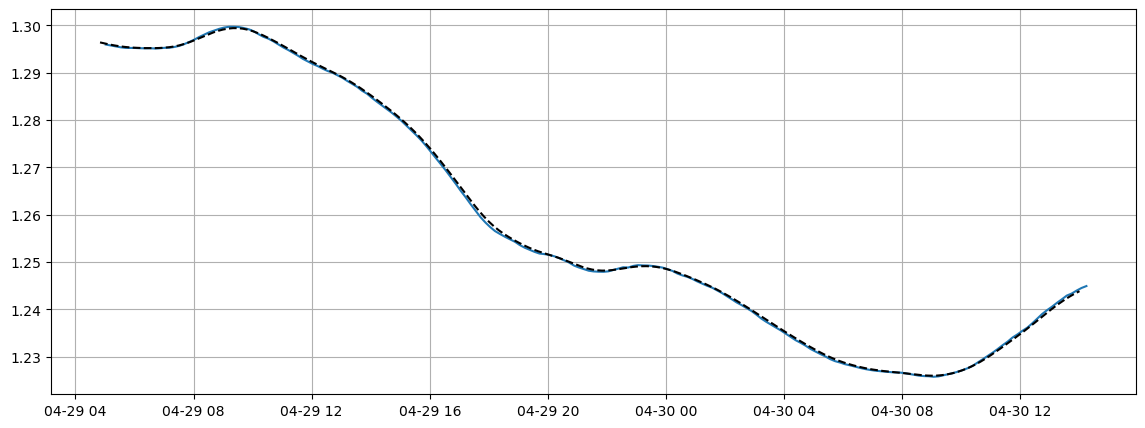

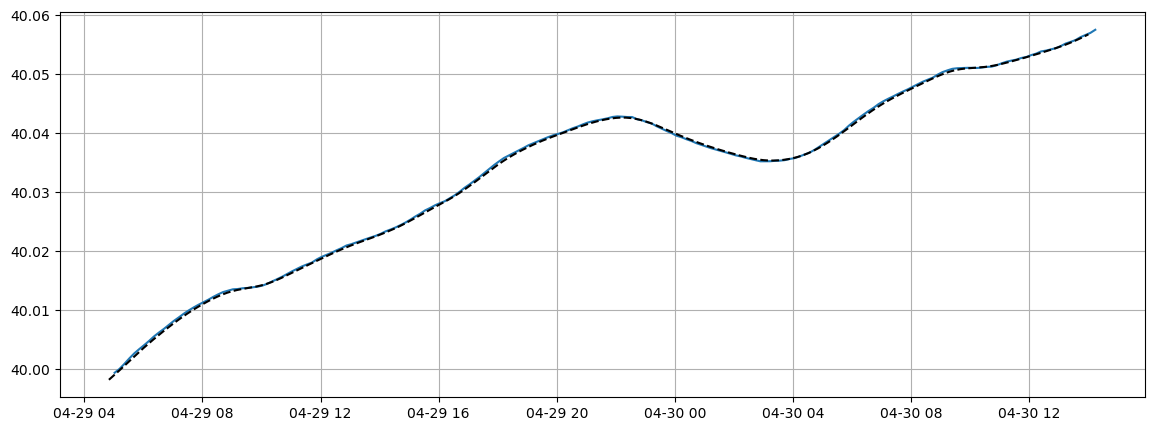

3


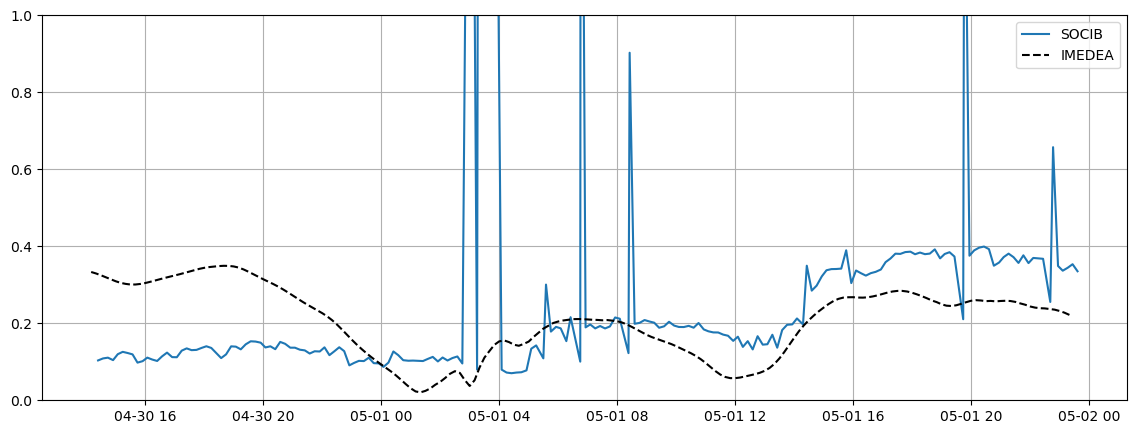

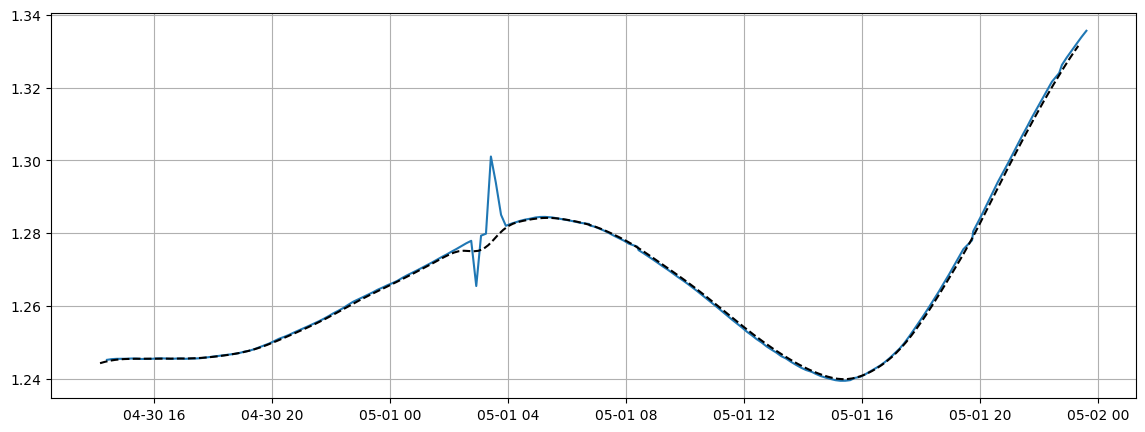

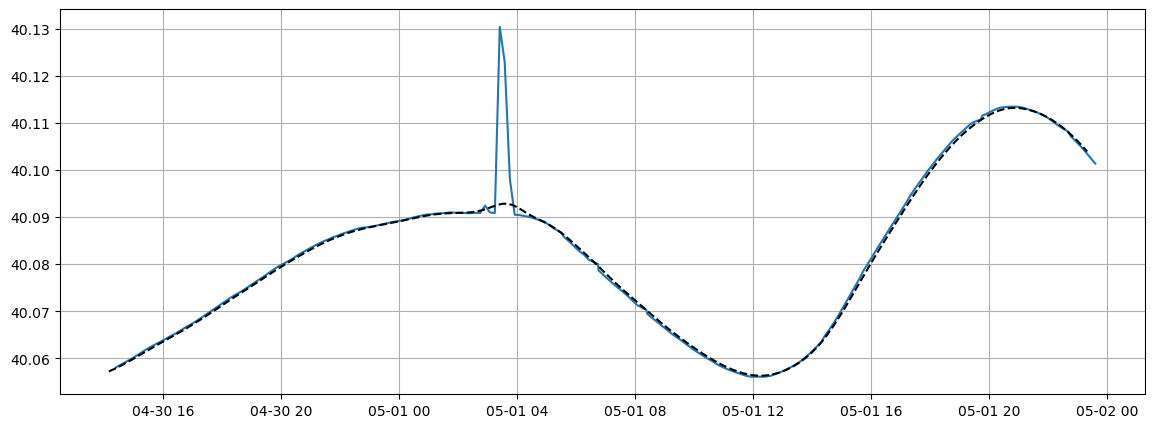

4


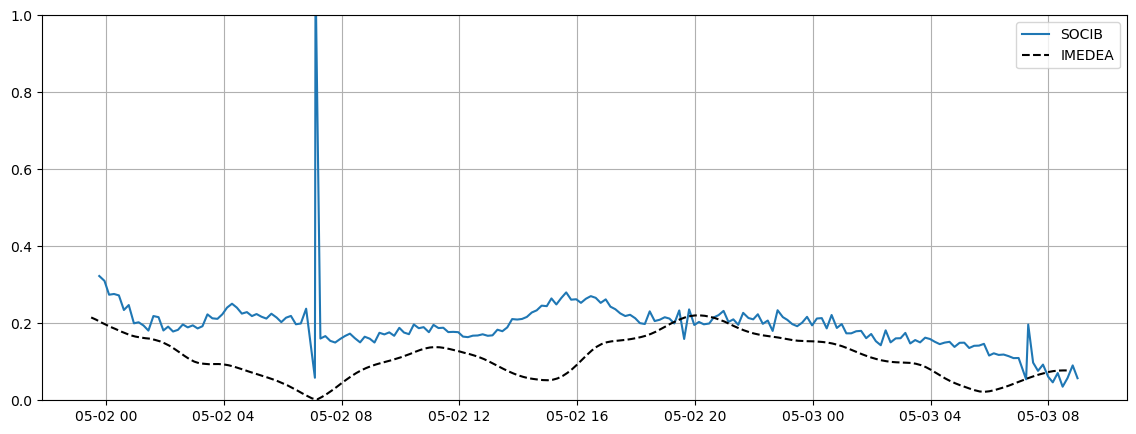

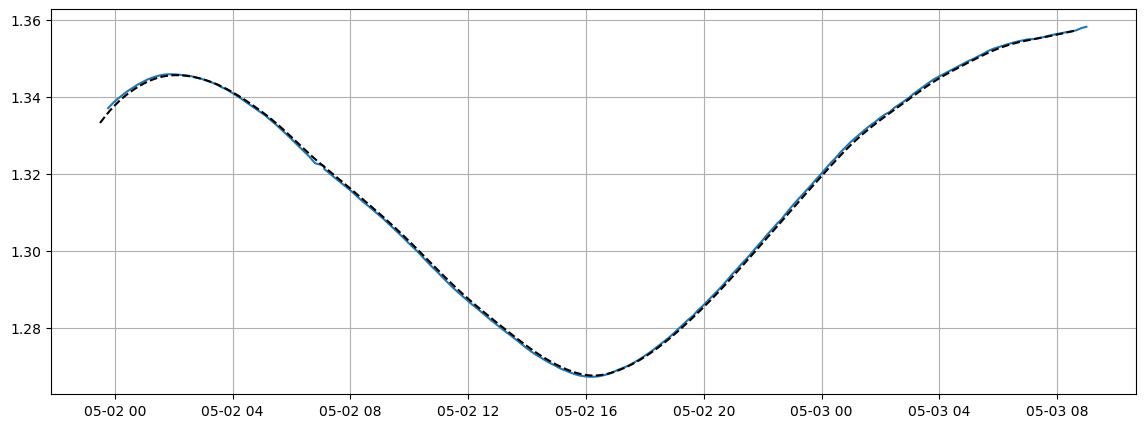

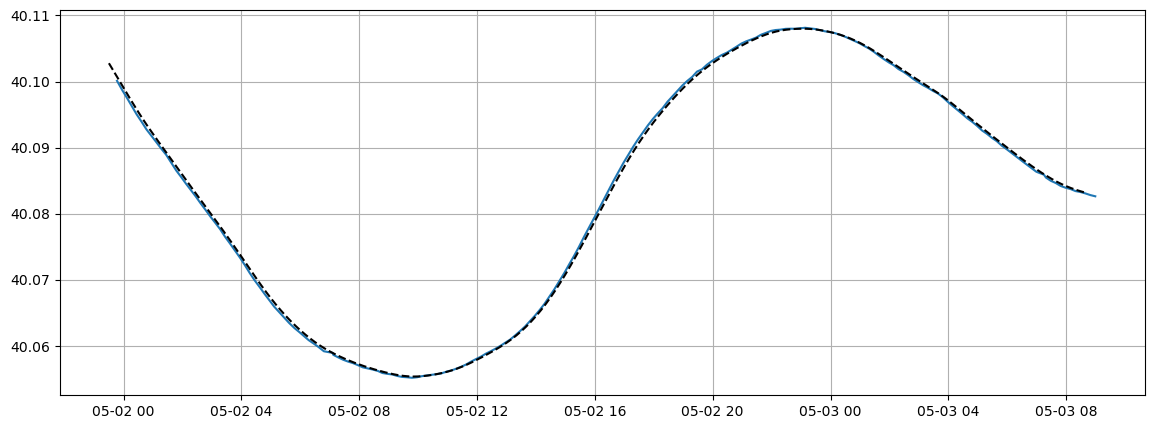

5


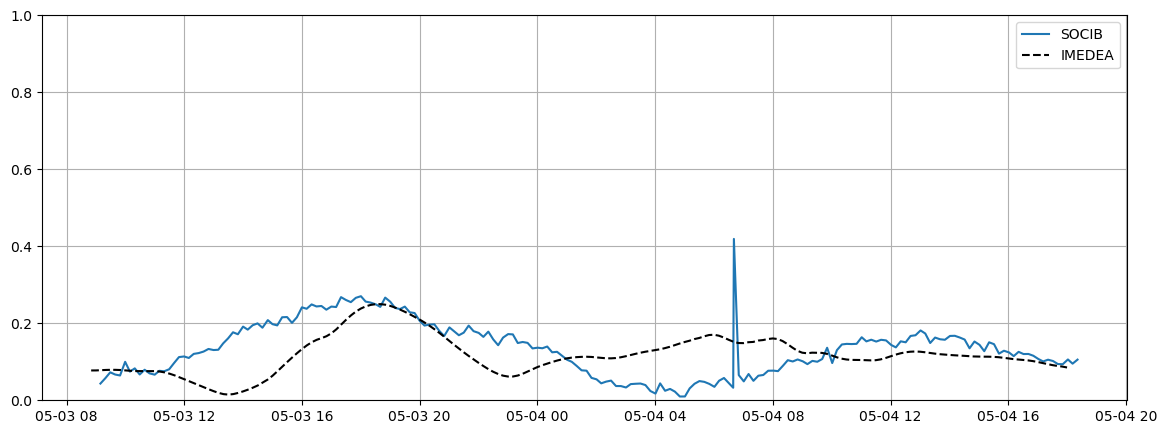

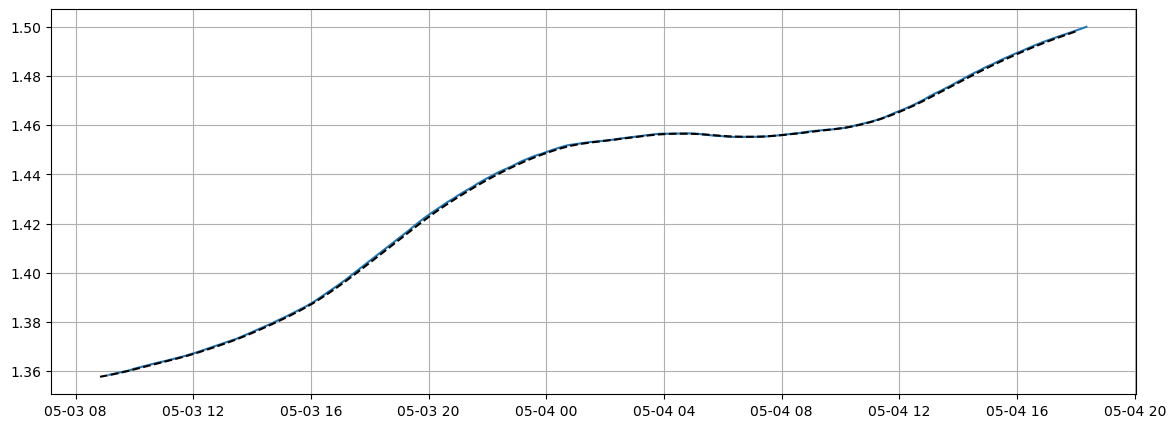

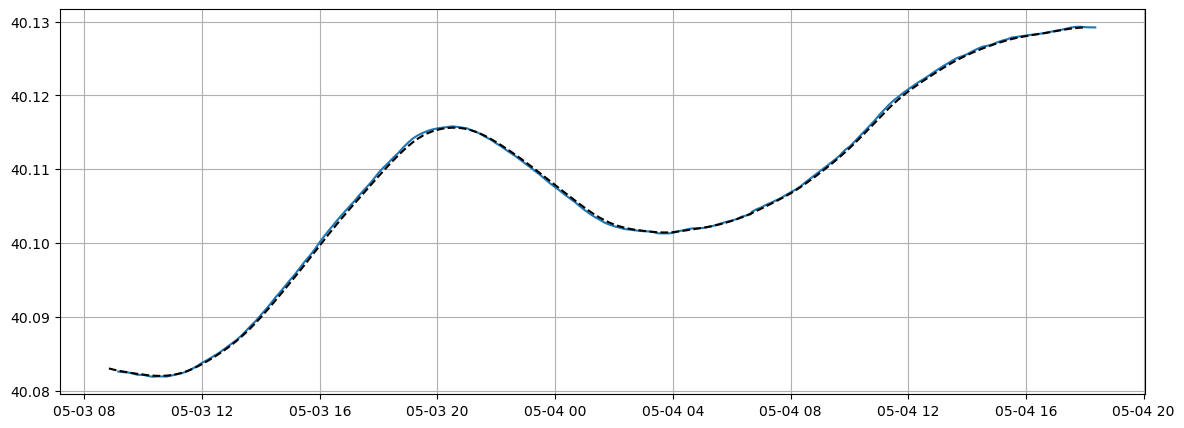

6


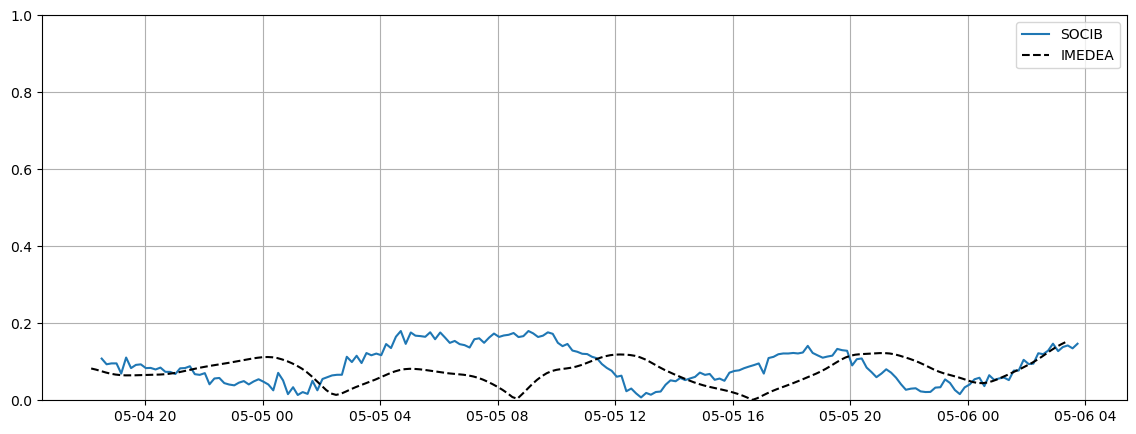

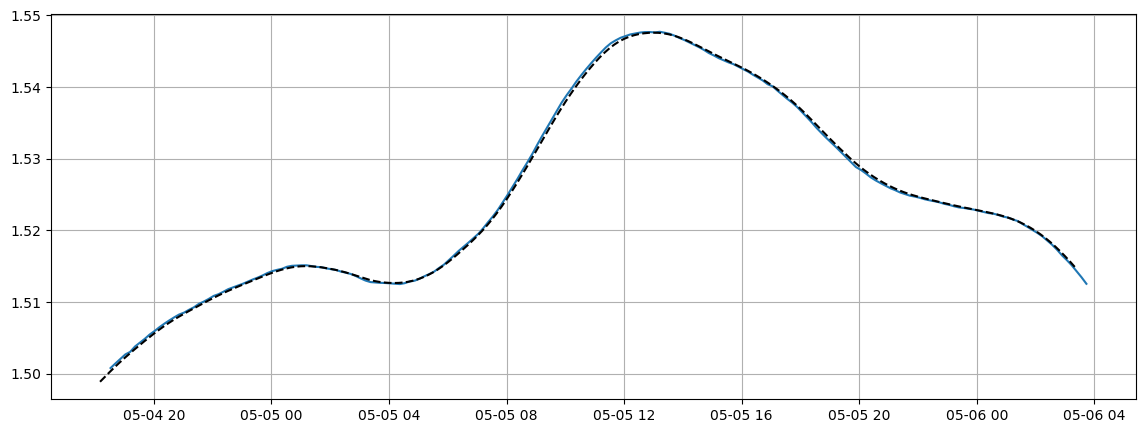

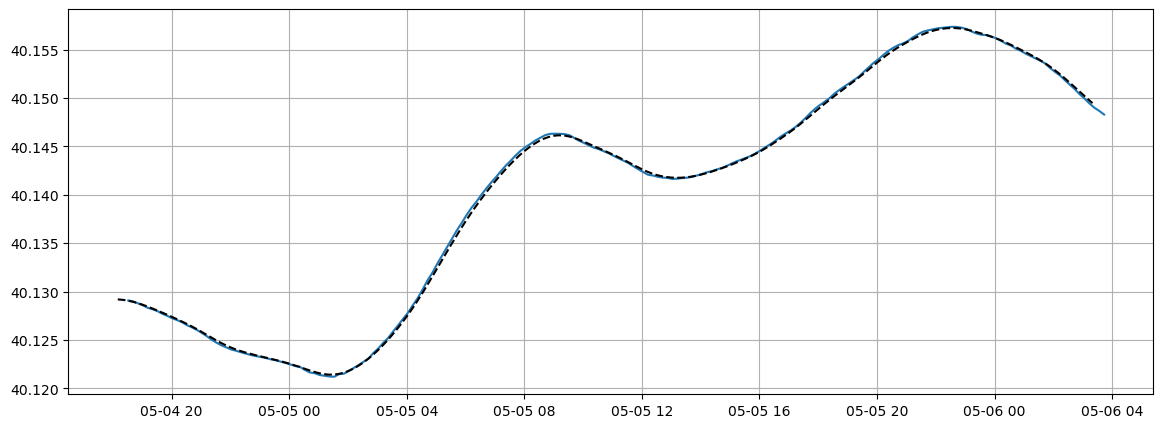

7


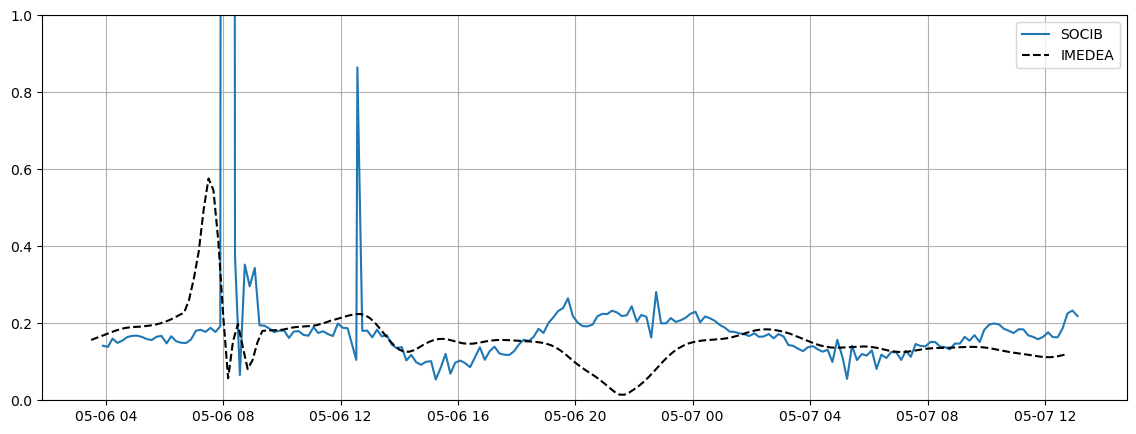

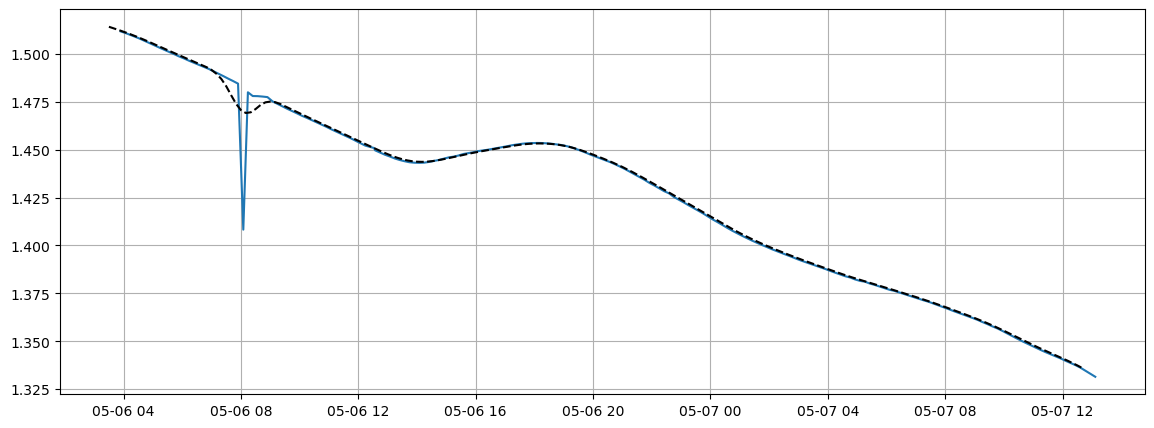

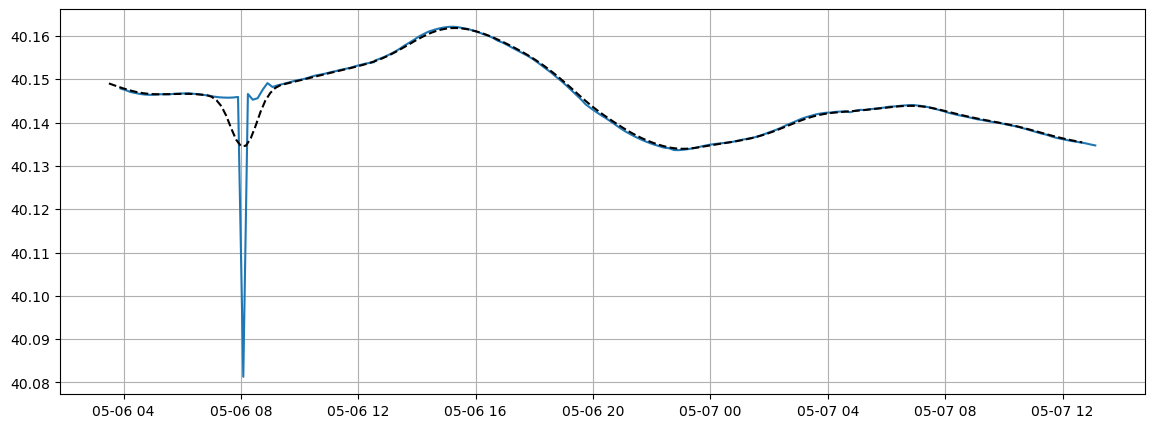

8


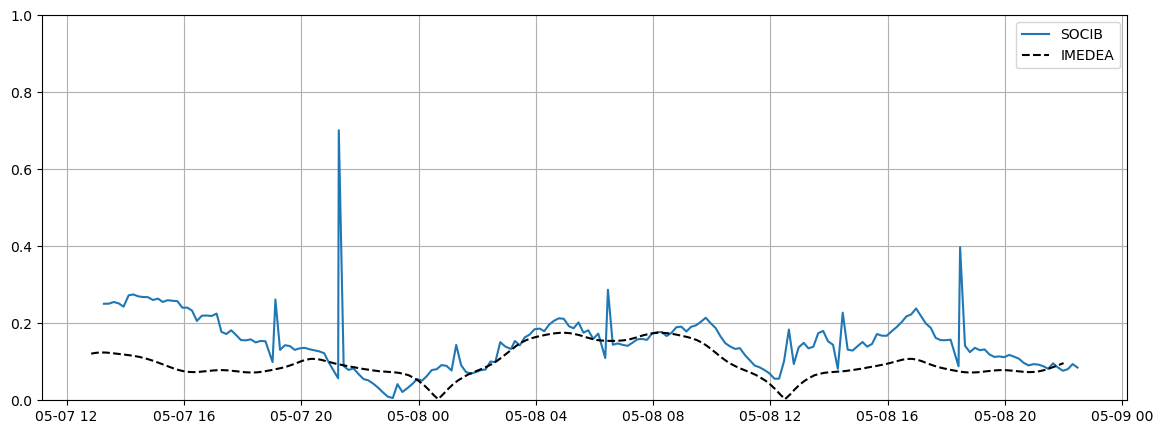

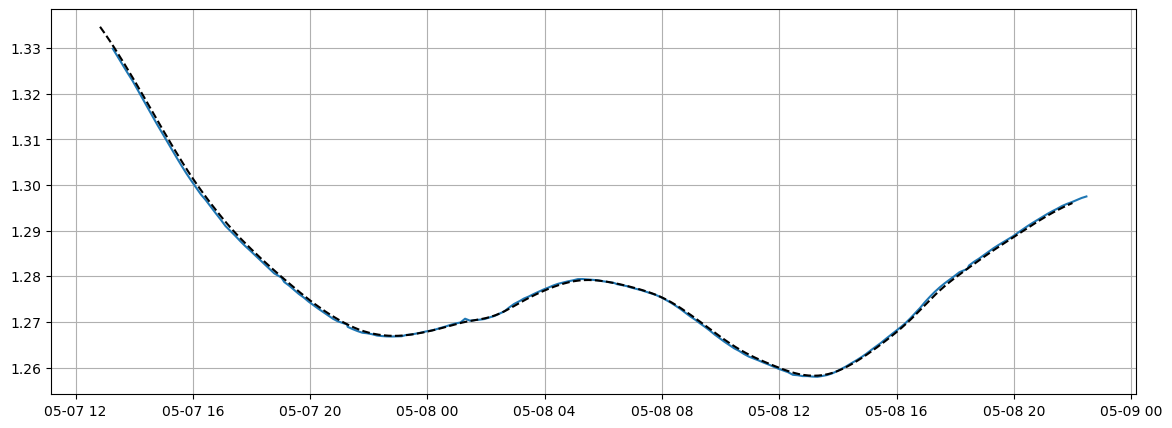

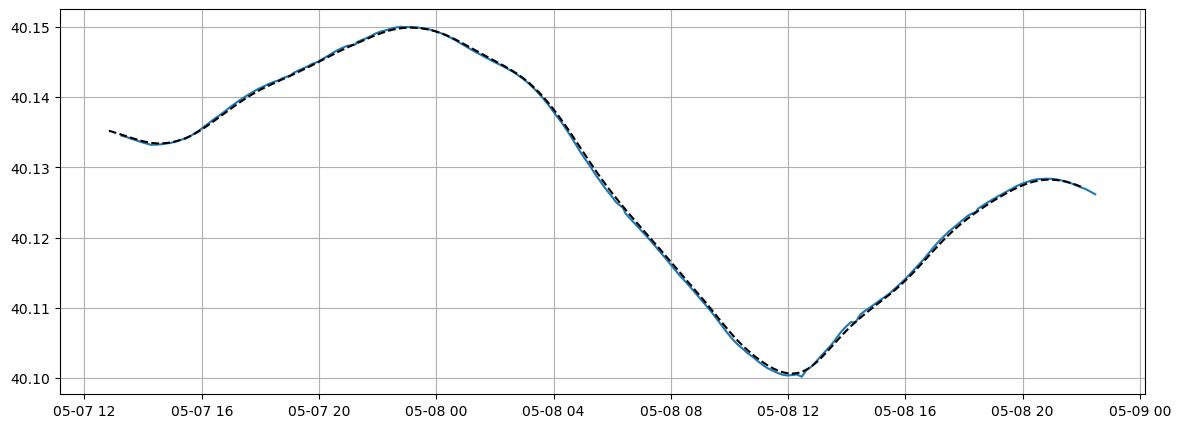

9


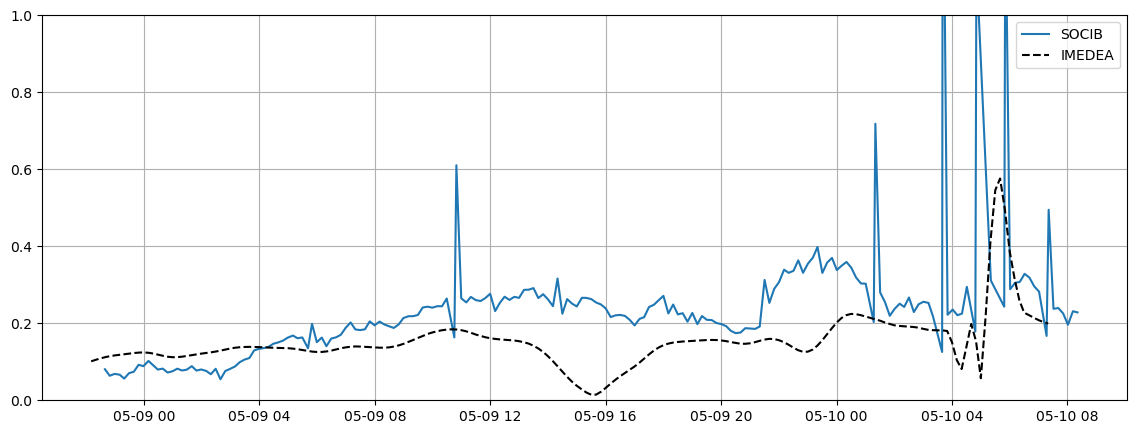

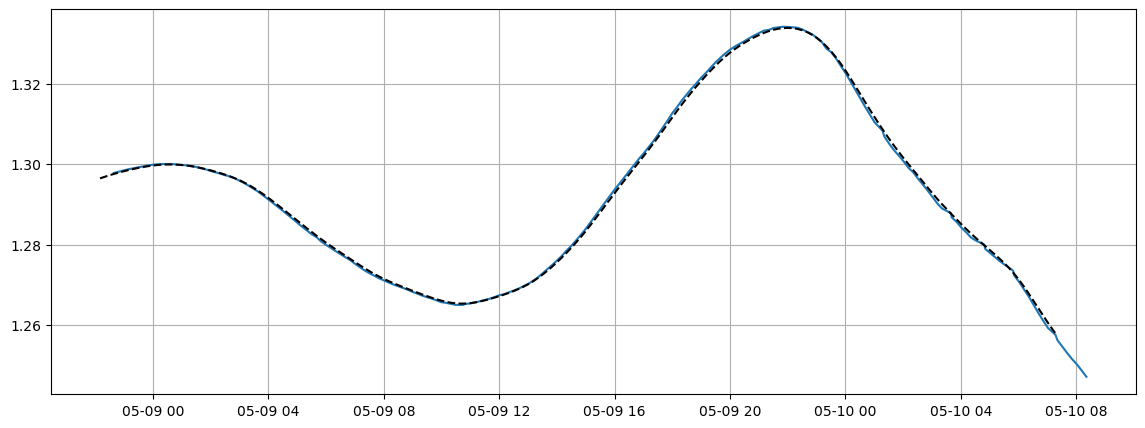

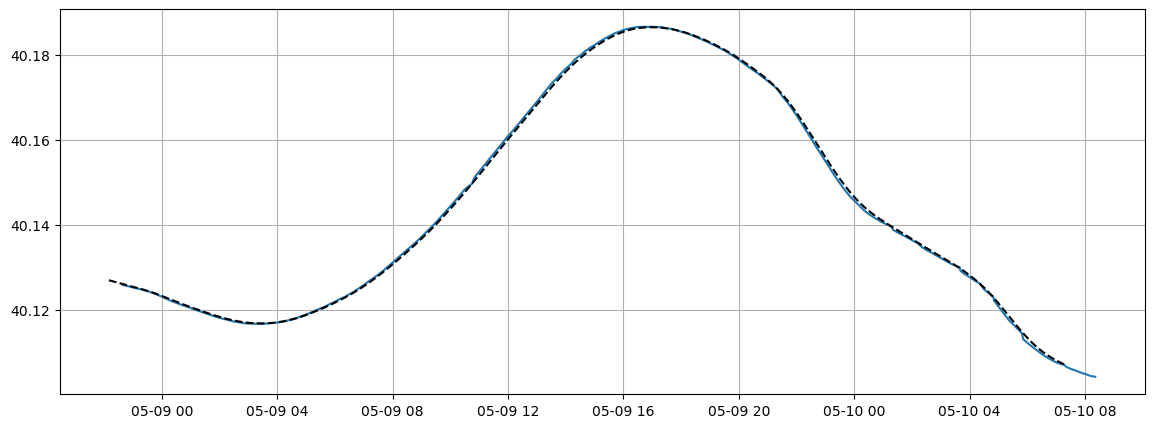

10


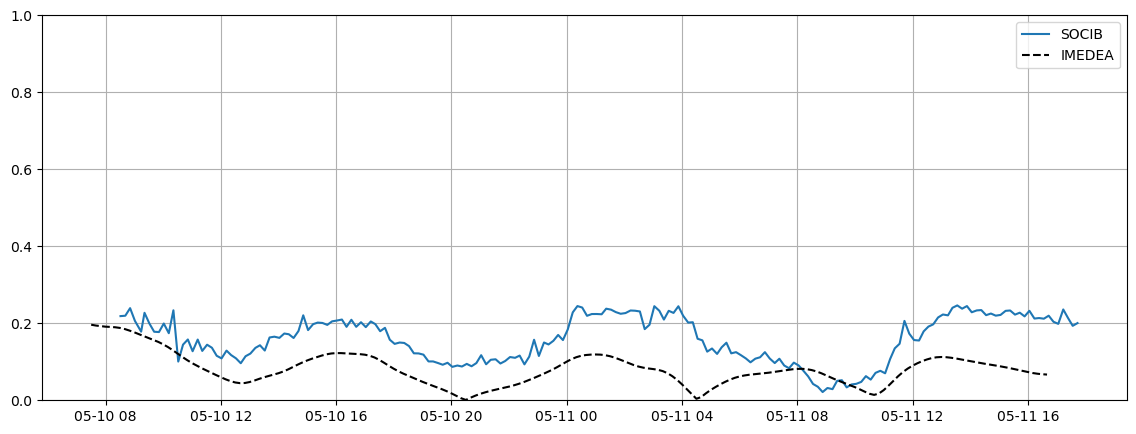

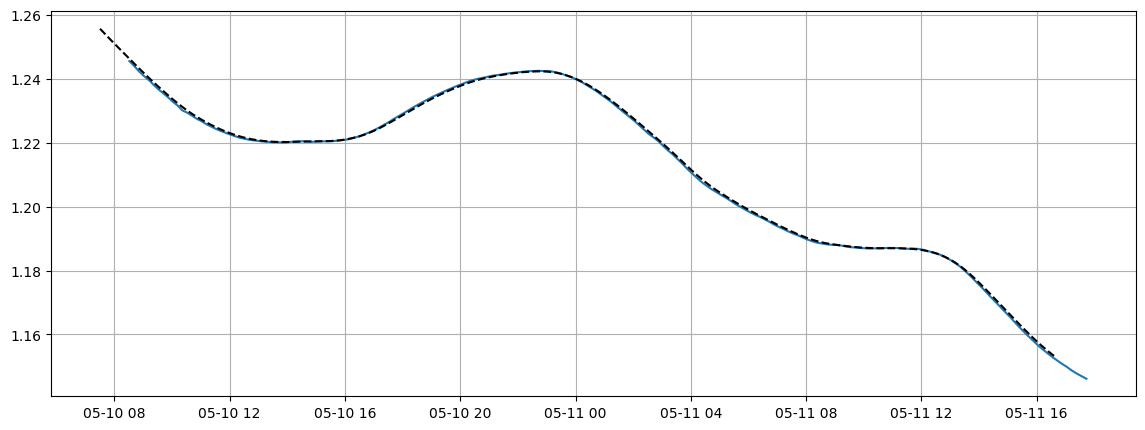

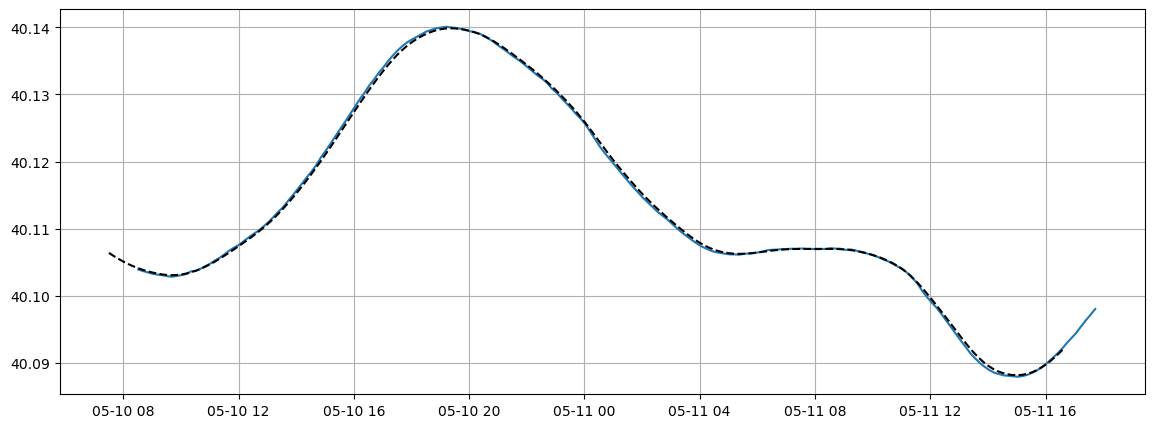

11


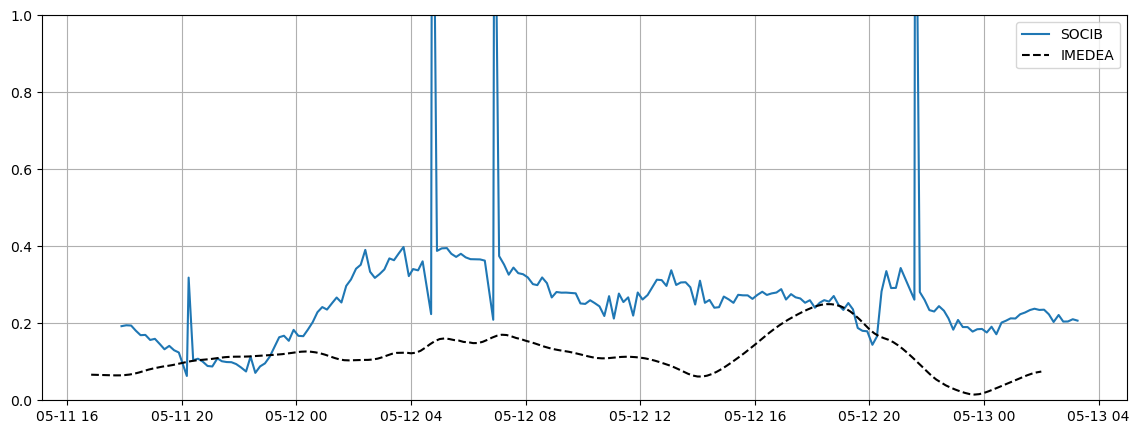

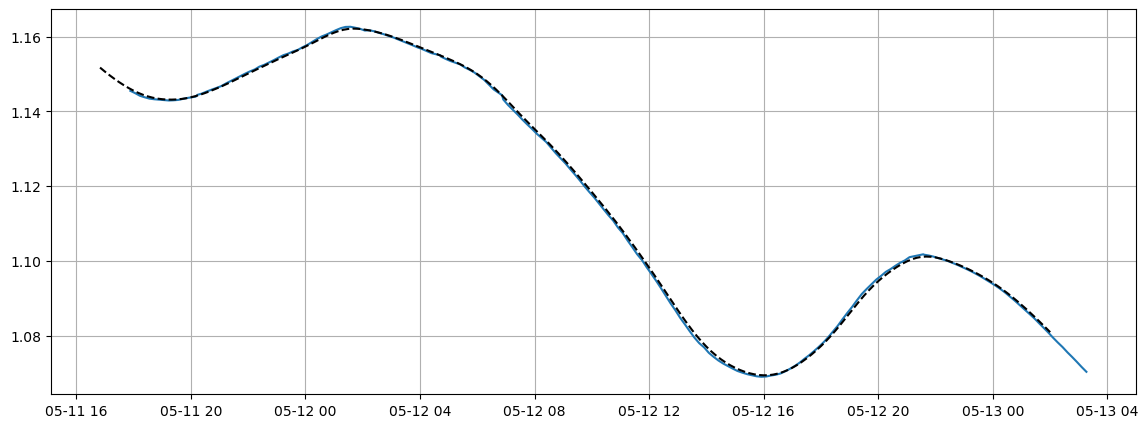

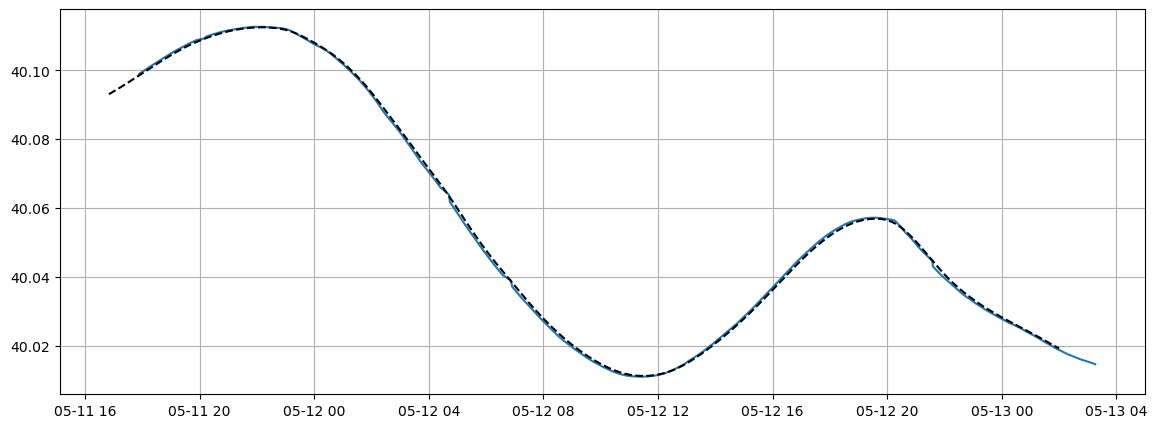

12


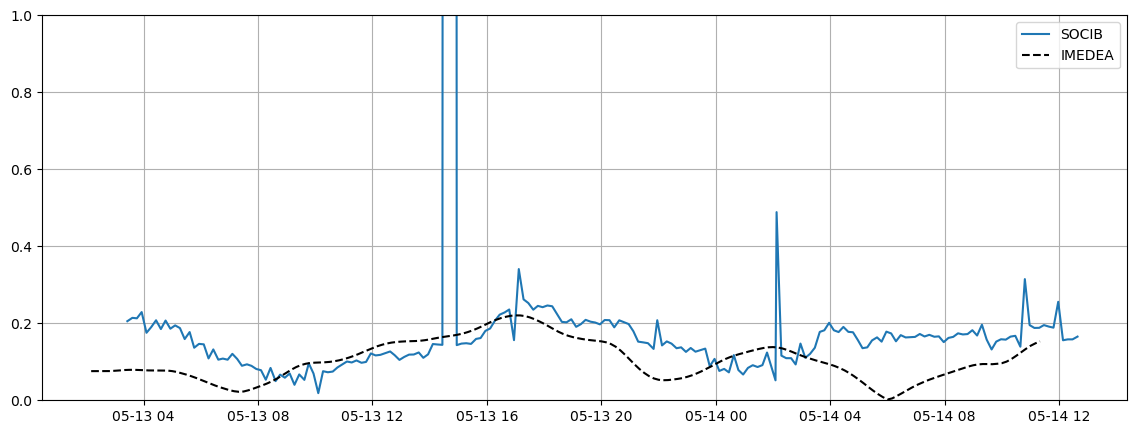

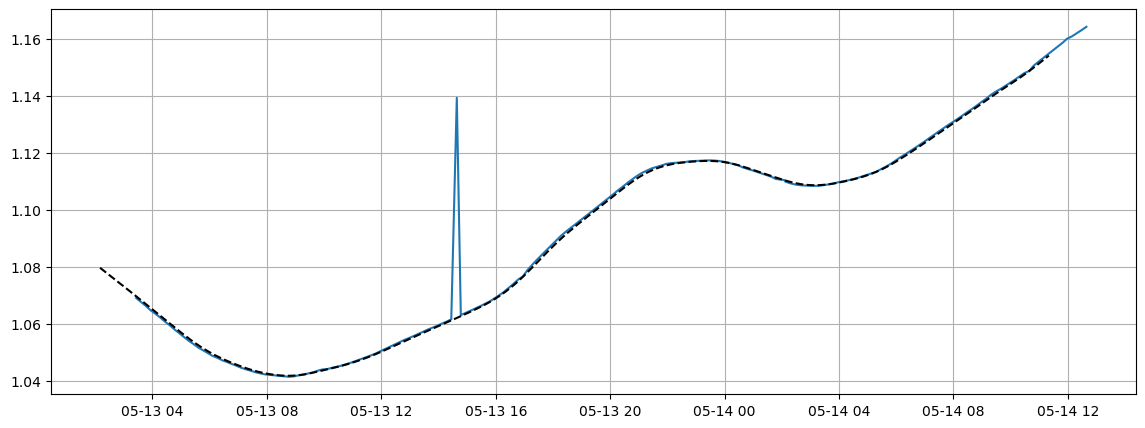

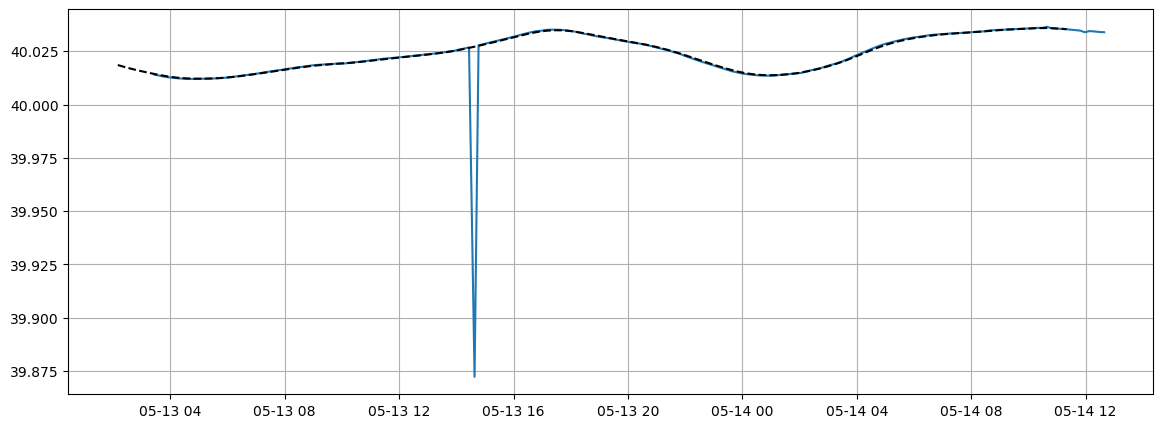

13


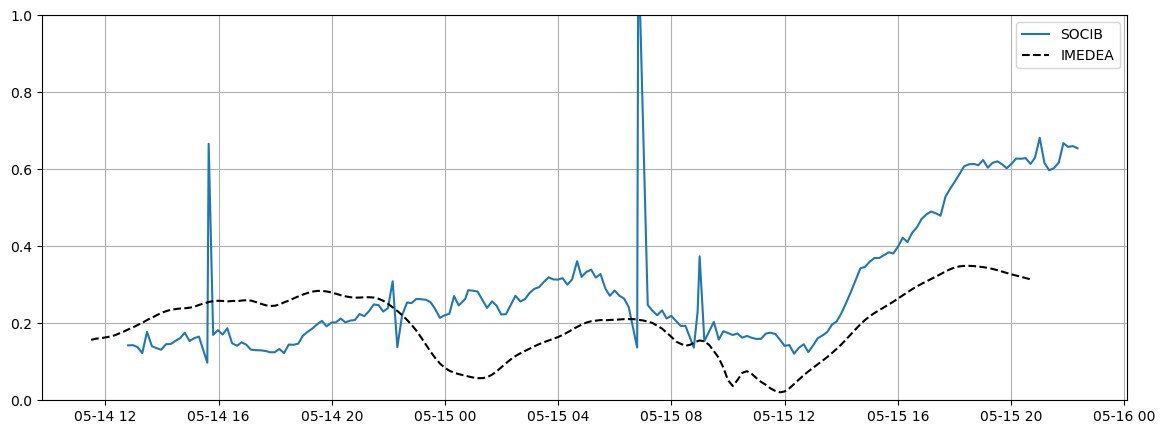

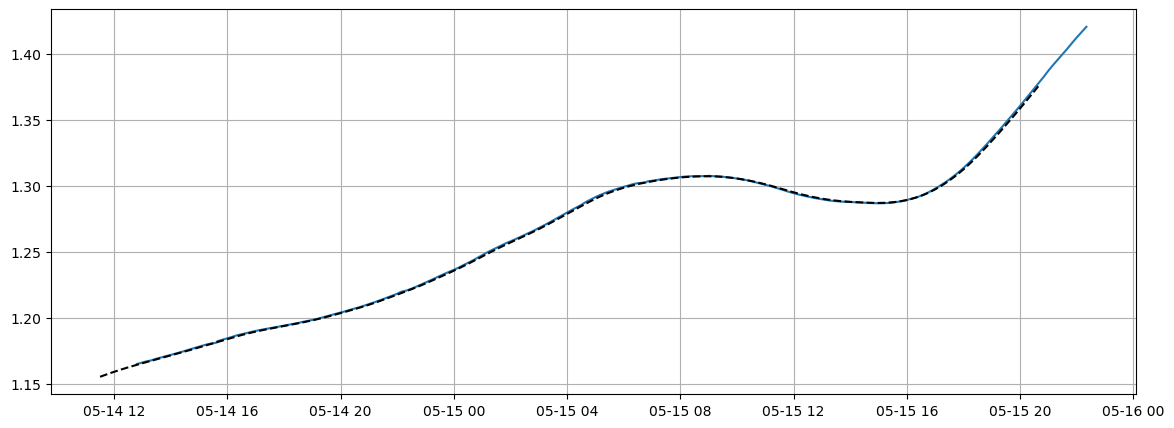

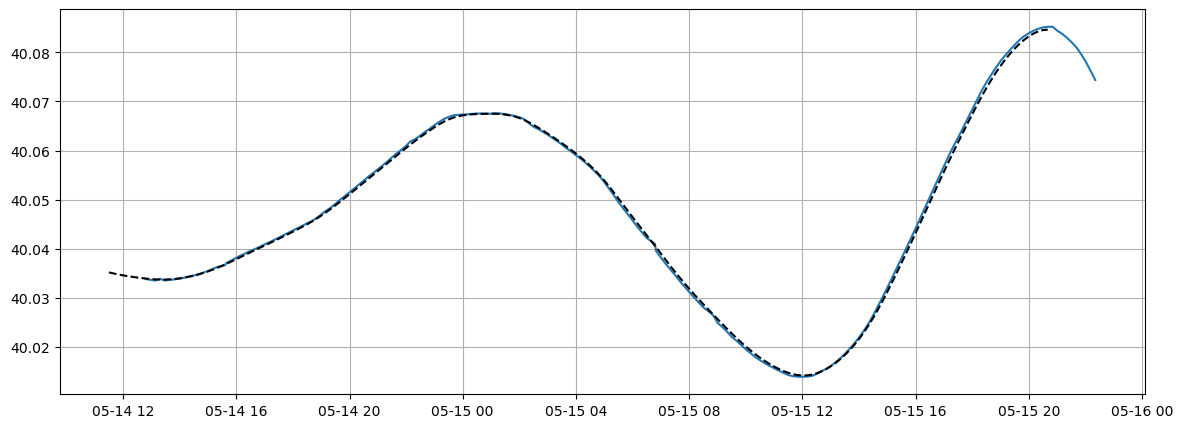

14


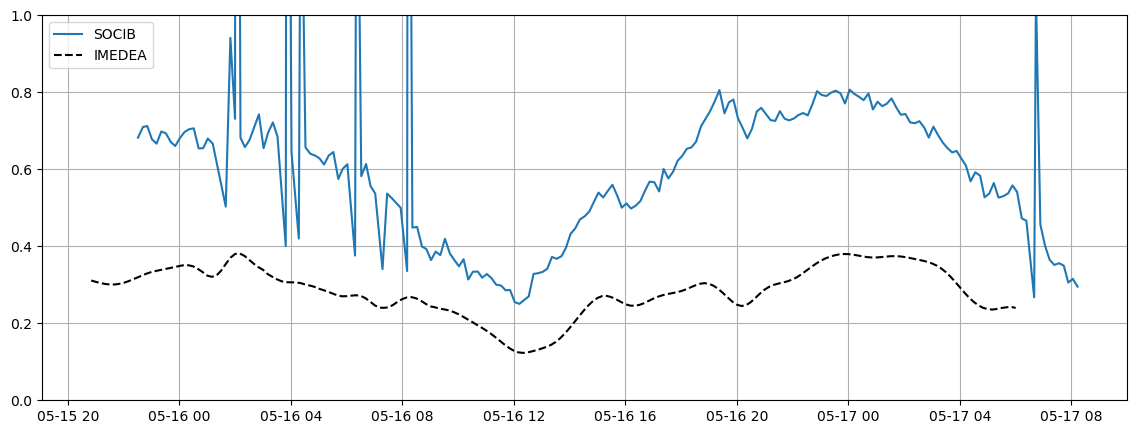

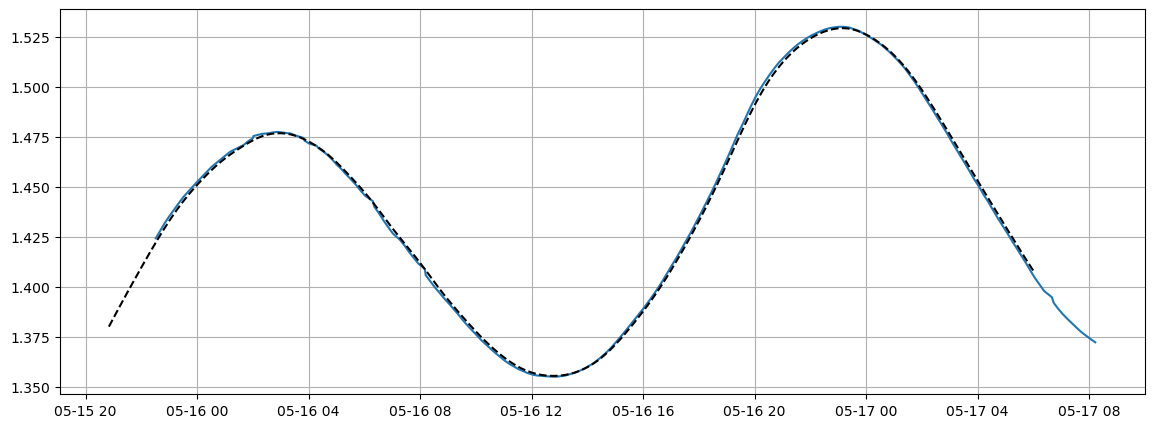

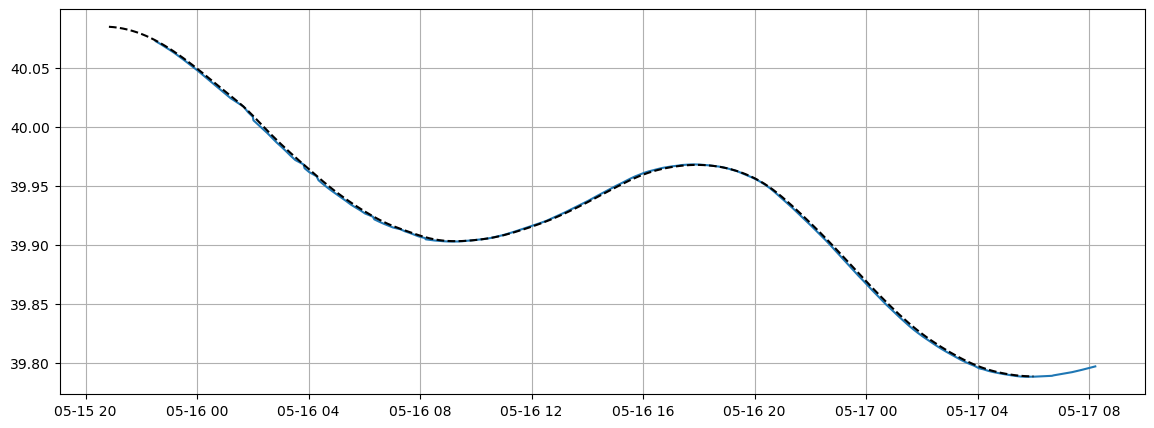

15


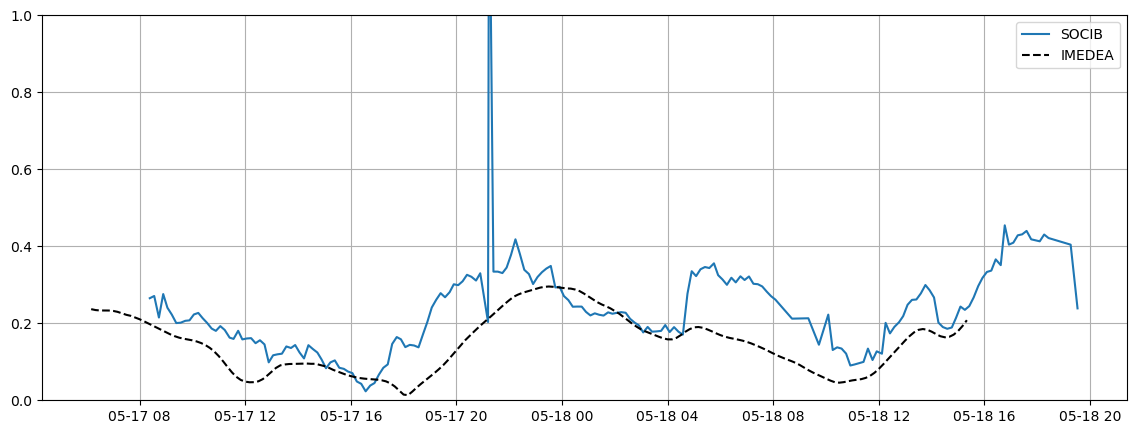

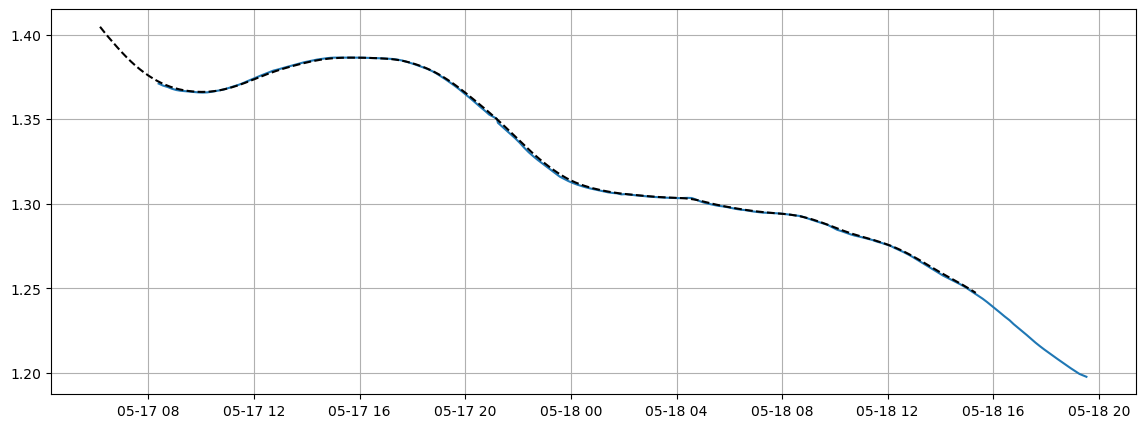

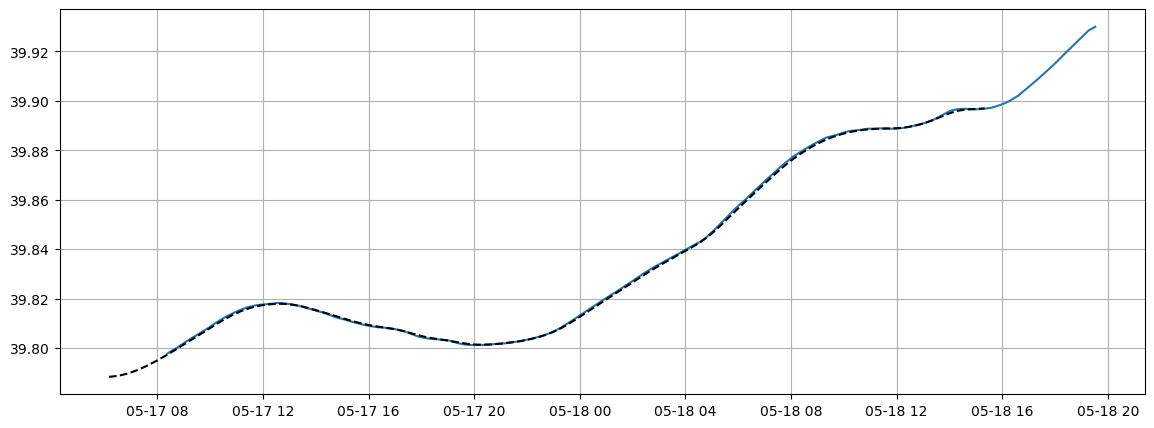

16


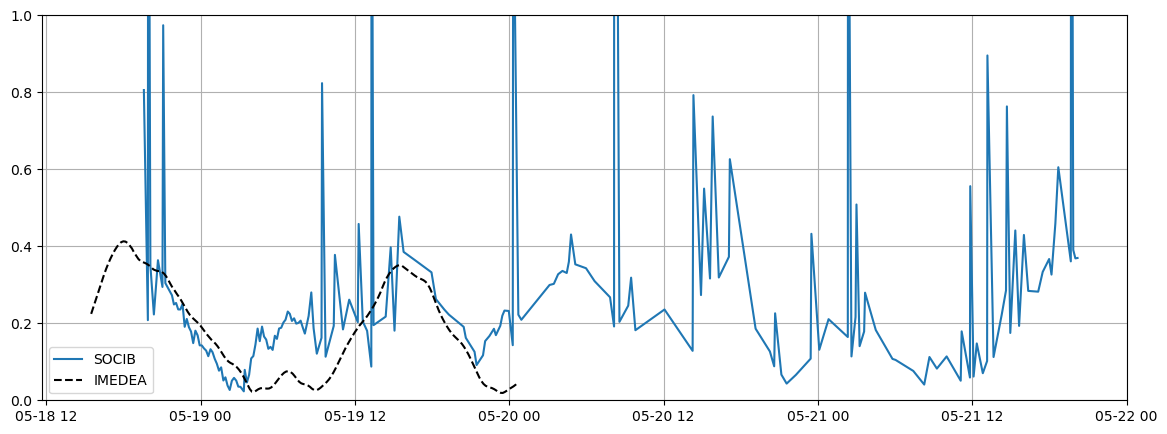

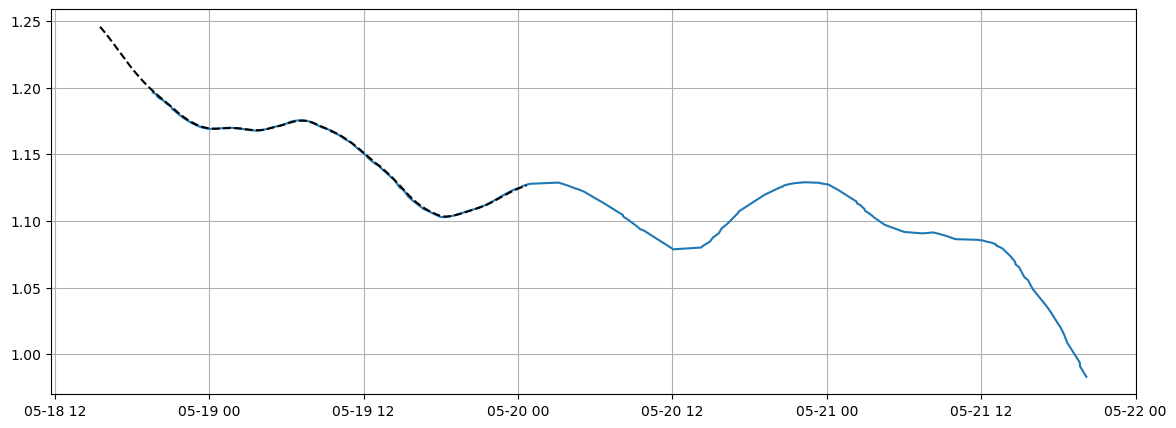

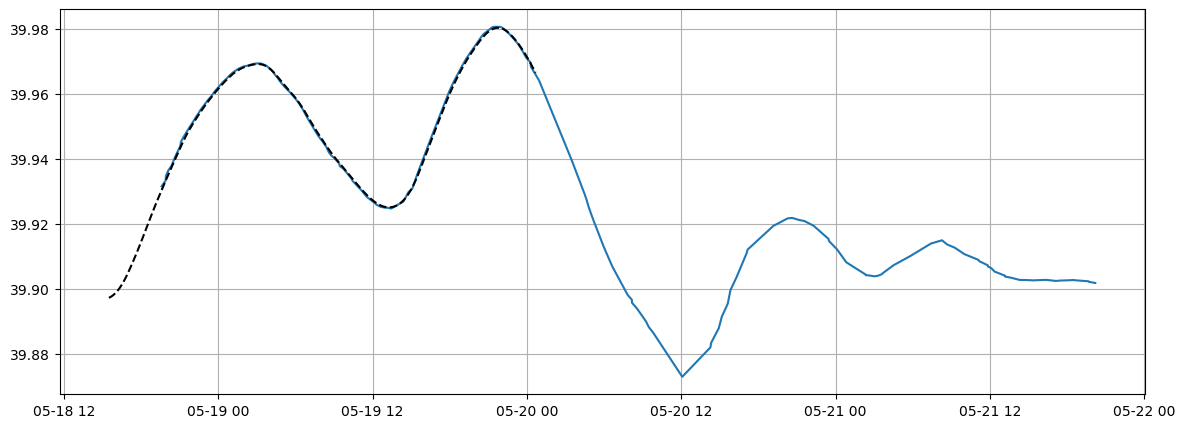

In [41]:
# to visualize data gaps:
for ii in range(0, int(np.floor(len(abs_vel_car001_IMEDEA)/200.))):
    print(ii)
    plt.figure(figsize=(14,5))
    plt.plot(ds_car001.time[(ii*200):((ii+1)*200)], ds_car001.PLAT_SPEED_GR[(ii*200):((ii+1)*200)], label='SOCIB')
    plt.plot(ds_car001_IMEDEA.time[(ii*200):((ii+1)*200)], abs_vel_car001_IMEDEA[(ii*200):((ii+1)*200)], '--k', label='IMEDEA')
    plt.ylim([0,1])
    plt.legend()
    plt.grid()
    plt.figure(figsize=(14,5))
    plt.plot(ds_car001.time[(ii*200):((ii+1)*200)], ds_car001.LON[(ii*200):((ii+1)*200)], label='SOCIB')
    plt.plot(ds_car001_IMEDEA.time[(ii*200):((ii+1)*200)], ds_car001_IMEDEA.LON[(ii*200):((ii+1)*200)], '--k', label='IMEDEA')
    plt.grid()
    plt.figure(figsize=(14,5))
    plt.plot(ds_car001.time[(ii*200):((ii+1)*200)], ds_car001.LAT[(ii*200):((ii+1)*200)], label='SOCIB')
    plt.plot(ds_car001_IMEDEA.time[(ii*200):((ii+1)*200)], ds_car001_IMEDEA.LAT[(ii*200):((ii+1)*200)], '--k', label='IMEDEA')
    plt.grid()
    plt.show()